# XGBoost

In [4]:
# Data Handling and Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

###
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

###
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


ImportError: cannot import name '_get_additional_lbfgs_options_dict' from 'sklearn.utils.fixes' (/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/fixes.py)

In [70]:
# Read csv file and look at contents
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(file_path, sep=";", na_values=["", " ", "NA", "N/A", "nan", "NaN"])

print(df.shape)
print(df.head())

# Proportions of classes
print("Value Counts (in %):")
class_shares = df["OUTCOME_3Kat_KHK"].value_counts(normalize=True) * 100
print(class_shares.round(2))
print("Number of nan")
print(df.isnull().sum())
df.isnull().sum().sort_values(ascending=False).head(20)

# Gesamtanzahl leerer Zellen im gesamten DataFrame
print("Gesamtanzahl Zellen:", df.size)
print("Gesamtanzahl leerer Zellen:", df.isnull().sum().sum())

cat_cols = df.select_dtypes(include=["object", "category"]).columns
print("C")
print(cat_cols.tolist())


(2310, 649)
   OUTCOME_3Kat_KHK           Alter_0  geschlecht waist_0             WHR_0  \
0                 2  56,9691991786448           0     112  ,982456140350877   
1                 2  69,4976043805613           0     104              1,04   
2                 2  72,0492813141684           0     129  ,941605839416058   
3                 2  70,8145106091718           0      99  ,876106194690266   
4                 2  62,1601642710472           1     125               NaN   

              BMI_0  currsmo0  RR_syst_0  RR_diast_0  Pulse_Pressure  ...  \
0  32,8731097961867         0      130.0        80.0            50.0  ...   
1  30,1102788964583         0      160.0        70.0            90.0  ...   
2  44,7348800491207         0      140.0        90.0            50.0  ...   
3  26,2595847484332         0      130.0        90.0            40.0  ...   
4  42,4366343891054         1      180.0       100.0            80.0  ...   

   SMC231l  SMC232l  SMC233l  SMC240l  SMC241l SMC

## FIRST TRY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

# ---------------------------
# 1) Load data
# ---------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None]
)

# ---------------------------
# 2) Clean structure
#    - Drop columns that are mostly empty (>95% NaN)
#    - Drop rows that are entirely empty
# ---------------------------
before_cols = set(df.columns)
df = df.dropna(axis=1, thresh=len(df) * 0.05)  # keep cols with >=5% non-NaN
df = df.dropna(how="all")
dropped_cols = sorted(list(before_cols - set(df.columns)))

# ---------------------------
# 3) Target / features
# ---------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found after cleaning.")

# remove rows where target is missing
df = df[df[target_col].notna()]

X = df.drop(columns=[target_col])
y = df[target_col]

# ---------------------------
# 4) Encode categoricals (XGBoost needs numeric)
#    (keep NaNs; XGBoost can handle them)
# ---------------------------
X = pd.get_dummies(X, drop_first=True)

# ---------------------------
# 5) Train-test split (stratified)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Helpful: class distribution
print("Class distribution (train):")
print(y_train.value_counts(normalize=True).sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).sort_index())
print()

# ---------------------------
# 6) Class weights (multiclass) -> sample_weight
# ---------------------------
classes = np.unique(y_train)
class_wts = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
wt_map = {c: w for c, w in zip(classes, class_wts)}
sw_train = y_train.map(wt_map).values

print("Class weights used:")
for c in classes:
    print(f"  class {c}: {wt_map[c]:.4f}")
print()

# ---------------------------
# 7) XGBoost model
# ---------------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    # tree_method="hist",  # uncomment for speed on larger data
)

# Fit with sample weights (handles imbalance)
xgb_model.fit(
    X_train, y_train,
    sample_weight=sw_train,
    eval_set=[(X_test, y_test)],  # simple monitoring
    verbose=False
)

# ---------------------------
# 8) Evaluation
# ---------------------------
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------------------------
# 9) (Optional) Show what was dropped
# ---------------------------
if dropped_cols:
    print("\nDropped columns (>95% missing):")
    for c in dropped_cols:
        print(" -", c)

# Quick check of remaining missingness (X can still contain NaNs)
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
print("\nTop 10 features by remaining missingness in X (post-encoding):")
print(missing_pct.head(10).round(2))

# ---------------------------
# 10) Multiclass ROC and Precision–Recall curves (OvR)
# ---------------------------
# Predict probabilities
y_score = xgb_model.predict_proba(X_test)

# Ensure consistent class order
classes_model = np.array(xgb_model.classes_)  # e.g., [0,1,2]
y_test_bin = label_binarize(y_test, classes=classes_model)

# Containers
fpr, tpr, roc_auc = {}, {}, {}
precision, recall, avg_precision = {}, {}, {}

valid_classes_roc = []
valid_classes_pr = []

# Per-class curves (skip classes without positives/negatives as needed)
for i, c in enumerate(classes_model):
    y_true_i = y_test_bin[:, i]
    y_score_i = y_score[:, i]

    # ROC needs both positives and negatives
    if y_true_i.any() and (~y_true_i.astype(bool)).any():
        fpr[i], tpr[i], _ = roc_curve(y_true_i, y_score_i)
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid_classes_roc.append(i)

    # PR needs at least one positive
    if y_true_i.any():
        precision[i], recall[i], _ = precision_recall_curve(y_true_i, y_score_i)
        avg_precision[i] = average_precision_score(y_true_i, y_score_i)
        valid_classes_pr.append(i)

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
avg_precision["micro"] = average_precision_score(y_test_bin, y_score, average="micro")

# Macro-average (mean over available classes)
roc_auc["macro"] = float(np.mean([roc_auc[i] for i in valid_classes_roc])) if valid_classes_roc else np.nan
avg_precision["macro"] = float(np.mean([avg_precision[i] for i in valid_classes_pr])) if valid_classes_pr else np.nan

print(f"\nROC AUC — micro: {roc_auc['micro']:.3f}, macro: {roc_auc['macro']:.3f}")
print(f"Avg Precision — micro: {avg_precision['micro']:.3f}, macro: {avg_precision['macro']:.3f}")

/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_16080/2187469483.py:25: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Class distribution (train):
OUTCOME_3Kat_KHK
0    0.156926
1    0.273810
2    0.569264
Name: proportion, dtype: float64

Class distribution (test):
OUTCOME_3Kat_KHK
0    0.158009
1    0.272727
2    0.569264
Name: proportion, dtype: float64

Class weights used:
  class 0: 2.1241
  class 1: 1.2174
  class 2: 0.5856



/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [13:46:56] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


KeyboardInterrupt: 

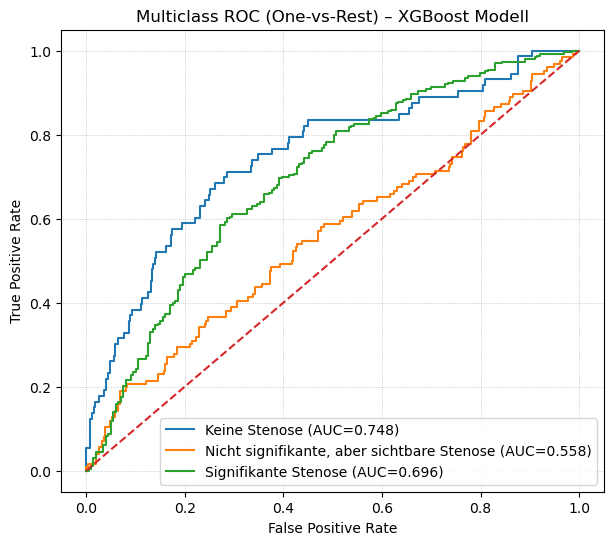

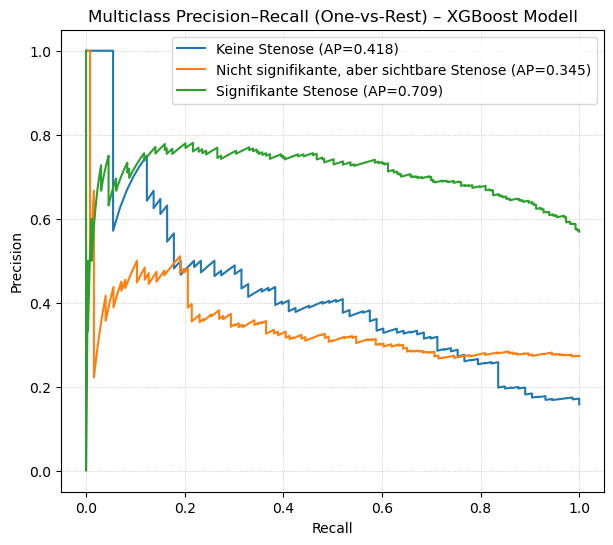

In [5]:
# Klassen-Beschriftungen definieren
class_labels = {
    0: "Keine Stenose",
    1: "Nicht signifikante, aber sichtbare Stenose",
    2: "Signifikante Stenose"
}

# ROC plot 
plt.figure(figsize=(7, 6))
for i in valid_classes_roc:
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (One-vs-Rest) – XGBoost Modell")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()

# Precision–Recall plot
plt.figure(figsize=(7, 6))
for i in valid_classes_pr:
    plt.plot(recall[i], precision[i], label=f"{class_labels[i]} (AP={avg_precision[i]:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall (One-vs-Rest) – XGBoost Modell")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.show()


## SMOTE VARIANT, MULTI-CLASS

In [2]:
# Multiclass XGBoost + SMOTENC (schnellere Variante, ohne n_jobs)
# - Drop >75% missing
# - Numerisch aussehende Strings -> Float (Dezimal-Komma)
# - Imputation NUR auf Train (median / most_frequent)
# - SMOTENC vor One-Hot, Minderheiten auf 60% der Mehrheit (statt voll)
# - One-Hot erst NACH SMOTE
# - Early Stopping, ROC/PR micro & macro

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# ---------------------------
# 1) Load + parse numeric-like strings
# ---------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# numeric-looking objects -> float
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if num.notna().mean() >= 0.80:
        df[c] = num

# ---------------------------
# 2) Drop columns with >75% missing (speed) + remove empty rows
# ---------------------------
missing_threshold = 0.75
before_cols = set(df.columns)
df = df.dropna(axis=1, thresh=int(len(df) * (1 - missing_threshold)))
df = df.dropna(how="all")
dropped_cols = sorted(list(before_cols - set(df.columns)))
print(f"Dropped {len(dropped_cols)} cols (> {int(missing_threshold*100)}% missing).")

# ---------------------------
# 3) Target / features (MULTICLASS 0/1/2)
# ---------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

df = df[df[target_col].notna()]
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# ---------------------------
# 4) Train-test split (stratified)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Class dist (train):")
print(y_train.value_counts(normalize=True).sort_index(), "\n")

# ---------------------------
# 5) Define numeric / categorical (low-card) columns on TRAIN
# ---------------------------
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_candidates = X_train.select_dtypes(exclude=np.number)
low_card_mask = cat_candidates.nunique() <= 30
cat_cols = low_card_mask[low_card_mask].index.tolist()

print(f"Numeric cols: {len(num_cols)} | Categorical (low-card) cols: {len(cat_cols)}")

# Reduce X to used columns (num + selected cat)
use_cols = num_cols + cat_cols
X_train = X_train[use_cols].copy()
X_test  = X_test[use_cols].copy()

# ---------------------------
# 6) Imputation (fit auf TRAIN, transform TRAIN/TEST)
#    - numeric: median
#    - categorical: most_frequent (Strings beibehalten)
# ---------------------------
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

Xtr_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]),
                       columns=num_cols, index=X_train.index)
Xte_num = pd.DataFrame(num_imputer.transform(X_test[num_cols]),
                       columns=num_cols, index=X_test.index)

if cat_cols:
    Xtr_cat = X_train[cat_cols].astype(str)
    Xte_cat = X_test[cat_cols].astype(str)
    Xtr_cat = pd.DataFrame(cat_imputer.fit_transform(Xtr_cat),
                           columns=cat_cols, index=X_train.index)
    Xte_cat = pd.DataFrame(cat_imputer.transform(Xte_cat),
                           columns=cat_cols, index=X_test.index)
    Xtr_imp = pd.concat([Xtr_num, Xtr_cat], axis=1)
    Xte_imp = pd.concat([Xte_num, Xte_cat], axis=1)
else:
    Xtr_imp, Xte_imp = Xtr_num, Xte_num

# ---------------------------
# 7) SMOTENC (schneller): im nicht-OHE-Raum, begrenztes Oversampling
# ---------------------------
from imblearn.over_sampling import SMOTENC, SMOTE

target_ratio = 0.60  # Minderheiten auf 60% der Mehrheit
counts = y_train.value_counts()
maj_class = counts.idxmax()
maj_count = counts.max()
sampling_strategy = {
    cls: int(maj_count * target_ratio)
    for cls, cnt in counts.items()
    if cls != maj_class and int(maj_count * target_ratio) > cnt
}

min_minority = min([cnt for cls, cnt in counts.items() if cls != maj_class], default=0)
k_neighbors = max(1, min(3, min_minority - 1))  # kleiner = schneller/stabiler

if cat_cols:
    cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
    sm = SMOTENC(
        categorical_features=cat_idx,
        sampling_strategy=sampling_strategy if sampling_strategy else "not majority",
        k_neighbors=k_neighbors,
        random_state=42
    )
else:
    sm = SMOTE(
        sampling_strategy=sampling_strategy if sampling_strategy else "not majority",
        k_neighbors=k_neighbors,
        random_state=42
    )

X_train_sm, y_train_sm = sm.fit_resample(Xtr_imp.values, y_train.values)
X_train_sm = pd.DataFrame(X_train_sm, columns=Xtr_imp.columns)

print("After SMOTENC/SMOTE class dist (train):")
print(pd.Series(y_train_sm).value_counts(normalize=True).sort_index())
print(f"Train size before: {len(y_train)} -> after: {len(y_train_sm)}")
print(f"SMOTE k_neighbors={k_neighbors}, target_ratio={target_ratio}\n")

# ---------------------------
# 8) One-Hot-Encoding NACH SMOTE (für XGBoost)
# ---------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=True)

ohe = make_ohe()
ct = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", ohe, cat_cols)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

X_train_enc = ct.fit_transform(X_train_sm)
X_test_enc  = ct.transform(Xte_imp)

# ---------------------------
# 9) XGBoost (multiclass) + Early Stopping
# ---------------------------
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.07,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
)

fit_kwargs = dict(
    X=X_train_enc, y=y_train_sm,
    eval_set=[(X_test_enc, y_test)],
    verbose=False
)
early_stopped = False
try:
    from xgboost.callback import EarlyStopping
    es = EarlyStopping(rounds=50, save_best=True, maximize=False)
    xgb.fit(**fit_kwargs, callbacks=[es]); early_stopped = True
except Exception:
    try:
        xgb.fit(**fit_kwargs, early_stopping_rounds=50); early_stopped = True
    except Exception:
        xgb.fit(**fit_kwargs)

print(f"Early stopping used: {early_stopped}")

# ---------------------------
# 10) Evaluation
# ---------------------------
y_pred = xgb.predict(X_test_enc)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# --- Multiclass ROC / PR (OvR) ---
y_score = xgb.predict_proba(X_test_enc)
classes_model = np.array(xgb.classes_)
y_test_bin = label_binarize(y_test, classes=classes_model)

fpr, tpr, roc_auc = {}, {}, {}
precision, recall, avg_precision = {}, {}, {}
valid_roc, valid_pr = [], []

for i, c in enumerate(classes_model):
    y_true_i = y_test_bin[:, i]
    y_score_i = y_score[:, i]
    if y_true_i.any() and (~y_true_i.astype(bool)).any():
        fpr[i], tpr[i], _ = roc_curve(y_true_i, y_score_i)
        roc_auc[i] = auc(fpr[i], tpr[i]); valid_roc.append(i)
    if y_true_i.any():
        precision[i], recall[i], _ = precision_recall_curve(y_true_i, y_score_i)
        avg_precision[i] = average_precision_score(y_true_i, y_score_i); valid_pr.append(i)

# micro/macro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
avg_precision["micro"] = average_precision_score(y_test_bin, y_score, average="micro")
roc_auc["macro"] = float(np.mean([roc_auc[i] for i in valid_roc])) if valid_roc else np.nan
avg_precision["macro"] = float(np.mean([avg_precision[i] for i in valid_pr])) if valid_pr else np.nan

print(f"\nROC AUC — micro: {roc_auc['micro']:.3f}, macro: {roc_auc['macro']:.3f}")
print(f"Avg Precision — micro: {avg_precision['micro']:.3f}, macro: {avg_precision['macro']:.3f}")

# --- quick plots ---
plt.figure(figsize=(7, 6))
for i in valid_roc:
    plt.plot(fpr[i], tpr[i], label=f"Class {classes_model[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (OvR)"); plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 6))
for i in valid_pr:
    plt.plot(recall[i], precision[i], label=f"Class {classes_model[i]} (AP={avg_precision[i]:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall (OvR)"); plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()

# ---------------------------
# 11) Diagnostics (optional)
# ---------------------------
print(f"\nFinal shapes: X_train_enc={getattr(X_train_enc, 'shape', None)}, X_test_enc={getattr(X_test_enc, 'shape', None)}")


ImportError: cannot import name '_get_additional_lbfgs_options_dict' from 'sklearn.utils.fixes' (/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/fixes.py)

## TOMEK LINKS, Multiclass

Class distribution (train):
OUTCOME_3Kat_KHK
0    0.156926
1    0.273810
2    0.569264
Name: proportion, dtype: float64

Class distribution (test):
OUTCOME_3Kat_KHK
0    0.158009
1    0.272727
2    0.569264
Name: proportion, dtype: float64

Class weights used:
  class 0: 2.1241
  class 1: 1.2174
  class 2: 0.5856

Early stopping used: False
Accuracy: 0.5822510822510822
Balanced accuracy: 0.429005754543543
Macro F1: 0.43397467666677675

Confusion Matrix:
 [[ 15  22  36]
 [  3  28  95]
 [ 10  27 226]]

Classification Report:
               precision    recall  f1-score   support

           0      0.536     0.205     0.297        73
           1      0.364     0.222     0.276       126
           2      0.633     0.859     0.729       263

    accuracy                          0.582       462
   macro avg      0.511     0.429     0.434       462
weighted avg      0.544     0.582     0.537       462


ROC AUC — micro: 0.748, macro: 0.645
Avg Precision — micro: 0.579, macro: 0.458


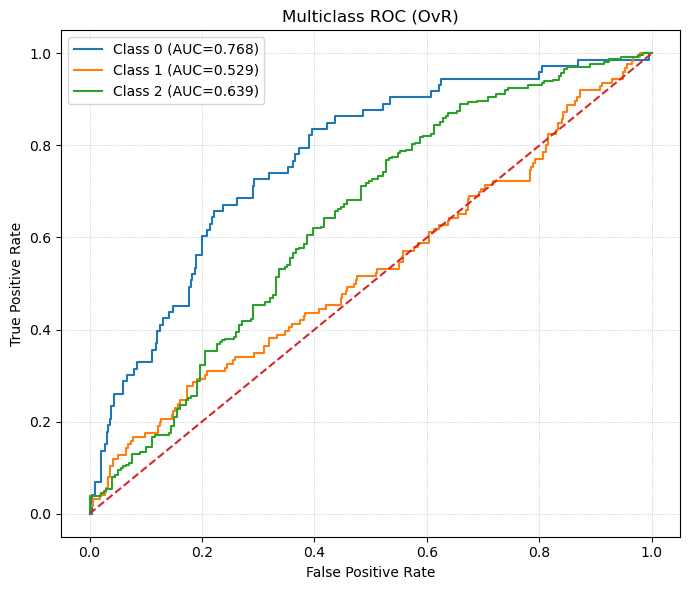

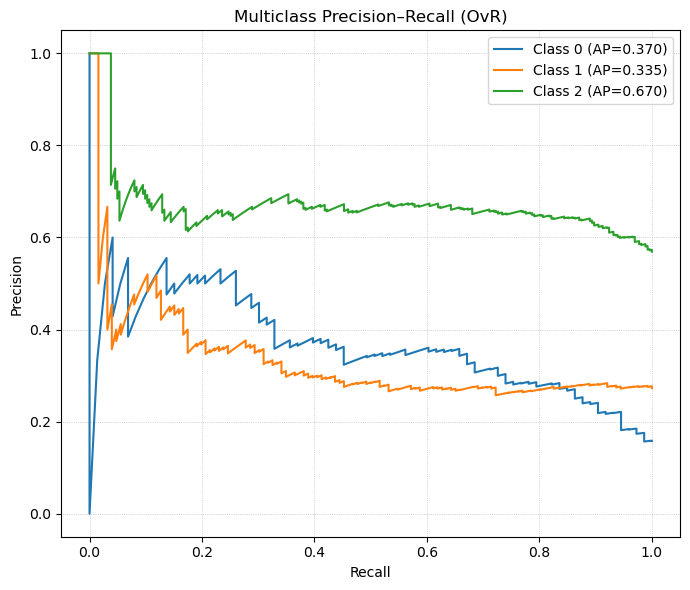


Dropped columns (>95% missing):
 - @12SHETE
 - @13SHODE
 - @15SHETE
 - @9SHODE
 - AA
 - ADMA
 - ANGPL4
 - AcOrn
 - Adiponectin_RIA
 - Ala
 - Apelin
 - Arg
 - Arg_energy_m
 - Asn
 - Asp
 - Asp_energy_m
 - Betatrophin
 - C0
 - C10
 - C101
 - C102
 - C12
 - C121
 - C12DC
 - C14
 - C141
 - C141OH
 - C142
 - C142OH
 - C16
 - C161
 - C161OH
 - C162
 - C162OH
 - C16OH
 - C18
 - C181
 - C181OH
 - C182
 - C2
 - C3
 - C31
 - C3DCC4OH
 - C3OH
 - C4
 - C41
 - C4OHC3DC
 - C5
 - C51
 - C51DC
... and 498 more

Top 10 features by remaining missingness in X (pre-imputation, native types):
ProBNP_0           67.45
GPC4_alle          66.19
PHOSPHAT           64.59
FGF23              64.55
CALCIUM            64.46
HGmax              63.42
oxLDL              63.25
NEUT_ABS_gesamt    61.26
LYMP_ABS_gesamt    61.21
Klotho             61.08
dtype: float64

Final shapes: X_train=(1848, 100), X_test=(462, 100)


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from pandas.api.types import is_numeric_dtype, is_categorical_dtype

# ---------------------------
# Config
# ---------------------------
FAST_MODE = True  # if True: try coercing 80%+ numeric-looking text to floats
FILE_PATH = "T49.2_Sep2025_1_StGallen.csv"
TARGET_COL = "OUTCOME_3Kat_KHK"
RANDOM_STATE = 42
TEST_SIZE = 0.20

# ---------------------------
# 1) Load data (faster CSV if PyArrow available)
# ---------------------------
read_kwargs = dict(
    sep=";",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False,
)
try:
    df = pd.read_csv(FILE_PATH, engine="pyarrow", **read_kwargs)
except Exception:
    df = pd.read_csv(FILE_PATH, **read_kwargs)

# ---------------------------
# 2) Basic cleaning
#    - Drop columns mostly empty (keep cols with >=5% non-NaN)
#    - Drop fully empty rows
# ---------------------------
before_cols = set(df.columns)
df = df.dropna(axis=1, thresh=int(len(df) * 0.25)) 
df = df.dropna(how="all")
dropped_cols = sorted(list(before_cols - set(df.columns)))

# ---------------------------
# 3) Target / features
# ---------------------------
if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found after cleaning.")
df = df[df[TARGET_COL].notna()]
y = df[TARGET_COL].astype(int)
X = df.drop(columns=[TARGET_COL])

# ---------------------------
# 4) Use native categoricals (skip get_dummies)
#    - Try coercing mostly-numeric text to floats if FAST_MODE
#    - Otherwise cast non-numeric columns to category
# ---------------------------
for c in X.columns:
    if not np.issubdtype(X[c].dtype, np.number):
        if FAST_MODE:
            coerced = pd.to_numeric(X[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
            if coerced.notna().mean() >= 0.80:
                X[c] = coerced
            else:
                X[c] = X[c].astype("category")
        else:
            X[c] = X[c].astype("category")

# ---------------------------
# 5) Train-test split (stratified)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Class distribution (train):")
print(y_train.value_counts(normalize=True).sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).sort_index())
print()

# Ensure any lingering object columns are explicitly categorical
for c in X_train.columns:
    if X_train[c].dtype == "object":
        X_train[c] = X_train[c].astype("category")
        X_test[c]  = X_test[c].astype("category")

# ---------------------------
# 6) Imputation (median for numeric only)
#    - Keep categoricals as-is; XGBoost handles NaN natively.
# ---------------------------
num_cols = [c for c in X_train.columns if is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if is_categorical_dtype(X_train[c])]

if len(num_cols) > 0:
    imputer = SimpleImputer(strategy="median")
    X_train_num_imp = pd.DataFrame(
        imputer.fit_transform(X_train[num_cols]),
        columns=num_cols, index=X_train.index
    )
    X_test_num_imp = pd.DataFrame(
        imputer.transform(X_test[num_cols]),
        columns=num_cols, index=X_test.index
    )
else:
    X_train_num_imp = pd.DataFrame(index=X_train.index)
    X_test_num_imp = pd.DataFrame(index=X_test.index)

# Reassemble and preserve original column order
X_train_imp = pd.concat([X_train_num_imp, X_train[cat_cols]], axis=1)
X_test_imp  = pd.concat([X_test_num_imp,  X_test[cat_cols]],  axis=1)
X_train_imp = X_train_imp[X_train.columns]
X_test_imp  = X_test_imp[X_test.columns]

# ---------------------------
# 7) Class weights (no TomekLinks for speed)
# ---------------------------
classes = np.sort(y_train.unique())
class_wts = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
wt_map = {c: w for c, w in zip(classes, class_wts)}
sw_train = y_train.map(wt_map).values

print("Class weights used:")
for c in classes:
    print(f"  class {c}: {wt_map[c]:.4f}")
print()

# ---------------------------
# 8) XGBoost (fast defaults + early stopping)
#    Tip: switch to tree_method='gpu_hist' if a CUDA GPU is available.
# ---------------------------
xgb_params = dict(
    n_estimators=300,            # rely on early stopping
    learning_rate=0.10,         # slightly higher for fewer rounds
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",         # 'gpu_hist' if GPU available
    enable_categorical=True,    # native categorical splits
    n_jobs=-1,
    max_bin=256,                # 128 for more speed if needed
    # grow_policy="lossguide",  # optional on wide data
)
xgb_model = XGBClassifier(**xgb_params)

fit_kwargs = dict(
    X=X_train_imp, y=y_train,
    sample_weight=sw_train,
    eval_set=[(X_test_imp, y_test)],
    verbose=False
)
early_stopped = False
try:
    from xgboost.callback import EarlyStopping
    es = EarlyStopping(rounds=40, save_best=True, maximize=False)
    xgb_model.fit(**fit_kwargs, callbacks=[es]); early_stopped = True
except Exception:
    try:
        xgb_model.fit(**fit_kwargs, early_stopping_rounds=40); early_stopped = True
    except Exception:
        xgb_model.fit(**fit_kwargs)
print(f"Early stopping used: {early_stopped}")

# ---------------------------
# 9) Evaluation
# ---------------------------
y_pred = xgb_model.predict(X_test_imp)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ---------------------------
# 10) Multiclass ROC & PR (OvR)
# ---------------------------
y_score = xgb_model.predict_proba(X_test_imp)
classes_model = np.array(xgb_model.classes_)
y_test_bin = label_binarize(y_test, classes=classes_model)

fpr, tpr, roc_auc = {}, {}, {}
precision, recall, avg_precision = {}, {}, {}
valid_classes_roc, valid_classes_pr = [], []

for i, c in enumerate(classes_model):
    y_true_i = y_test_bin[:, i]
    y_score_i = y_score[:, i]
    if y_true_i.any() and (~y_true_i.astype(bool)).any():
        fpr[i], tpr[i], _ = roc_curve(y_true_i, y_score_i)
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid_classes_roc.append(i)
    if y_true_i.any():
        precision[i], recall[i], _ = precision_recall_curve(y_true_i, y_score_i)
        avg_precision[i] = average_precision_score(y_true_i, y_score_i)
        valid_classes_pr.append(i)

# Micro averages
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
avg_precision["micro"] = average_precision_score(y_test_bin, y_score, average="micro")

# Macro averages
roc_auc["macro"] = float(np.mean([roc_auc[i] for i in valid_classes_roc])) if valid_classes_roc else np.nan
avg_precision["macro"] = float(np.mean([avg_precision[i] for i in valid_classes_pr])) if valid_classes_pr else np.nan

print(f"\nROC AUC — micro: {roc_auc['micro']:.3f}, macro: {roc_auc['macro']:.3f}")
print(f"Avg Precision — micro: {avg_precision['micro']:.3f}, macro: {avg_precision['macro']:.3f}")

# ---------------------------
# 11) Plots
# ---------------------------
plt.figure(figsize=(7, 6))
for i in valid_classes_roc:
    plt.plot(fpr[i], tpr[i], label=f"Class {classes_model[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (OvR)"); plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 6))
for i in valid_classes_pr:
    plt.plot(recall[i], precision[i], label=f"Class {classes_model[i]} (AP={avg_precision[i]:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Multiclass Precision–Recall (OvR)"); plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()

# ---------------------------
# 12) Info on dropped/missingness (optional)
# ---------------------------
if dropped_cols:
    print("\nDropped columns (>95% missing):")
    for c in dropped_cols[:50]:
        print(" -", c)
    if len(dropped_cols) > 50:
        print(f"... and {len(dropped_cols) - 50} more")

# Remaining missingness for training features (pre-imputation, post-typing)
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
print("\nTop 10 features by remaining missingness in X (pre-imputation, native types):")
print(missing_pct.head(10).round(2))

print(f"\nFinal shapes: X_train={X_train_imp.shape}, X_test={X_test_imp.shape}")


## SECOND TRY

Dropping 548 columns with >75% missingness.
Examples: ['CTRP1_restricted', 'Betatrophin', 'CHEMERIN', 'VISFATIN', 'ANGPL4', 'FETUIN_A_neu_berechnet', 'Apelin', 'Omentin', 'Adiponectin_RIA', 'Leptin_n']

Class distribution (train):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

Class distribution (test):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

scale_pos_weight: 0.757

Early stopping used: False

Accuracy: 0.6645021645021645
Balanced accuracy: 0.6509066243766359
F1 (binary): 0.7176684881602914

Confusion Matrix:
 [[110  89]
 [ 66 197]]

Classification Report:
               precision    recall  f1-score   support

           0      0.625     0.553     0.587       199
           1      0.689     0.749     0.718       263

    accuracy                          0.665       462
   macro avg      0.657     0.651     0.652       462
weighted avg      0.661     0.665     0.661       462


ROC AUC: 0.717
Average Precision (AP

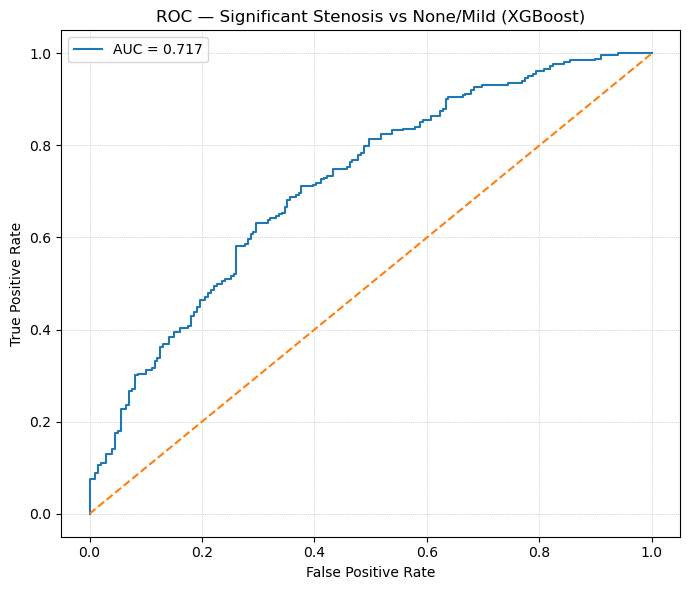

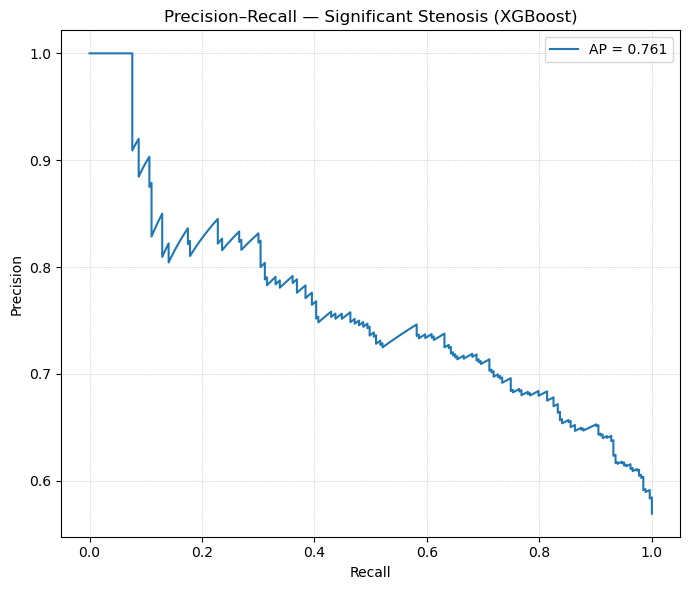


Top 15 features by remaining missingness in X (post-encoding):
ProBNP_0                       67.45
GPC4_alle                      66.19
PHOSPHAT                       64.59
FGF23                          64.55
CALCIUM                        64.46
HGmax                          63.42
oxLDL                          63.25
NEUT_ABS_gesamt                61.26
LYMP_ABS_gesamt                61.21
Klotho                         61.08
VitaminD                       60.30
Cer_d18_24_1_I_Cer_d18_24_0    60.26
Cer_d18_18_I_Cer_d18_24_0      60.26
Cer_d18_16_I_Cer_d18_24_0      60.26
Cer_d18_16                     60.22
dtype: float64

Final shapes: X_train=(1848, 100), X_test=(462, 100)


In [5]:
# XGBoost (Binary) mit Cleaning: Dezimal-Komma, >75% Missing-Drop, OHE; robustes Early Stopping & ROC/PR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# ---------------------------
# 1) Daten laden (Dezimal-Komma + sauberes NaN-Parsing)
# ---------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# ---------------------------
# 2) Obj->Float-Konvertierung für numerisch aussehende Spalten
# ---------------------------
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if num.notna().mean() >= 0.80:
        df[c] = num

# ---------------------------
# 3) Ziel & Features (binary mapping 0/1->0, 2->1)
# ---------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

y = (df[target_col] == 2).astype(int)     # 1 = signifikant, 0 = keine/milde
X = df.drop(columns=[target_col])

mask_target = y.notna()
X, y = X.loc[mask_target].copy(), y.loc[mask_target].copy()

# ---------------------------
# 4) Spalten mit >75% Missing entfernen (nur auf X)
# ---------------------------
missing_threshold = 0.75
missing_ratio = X.isna().mean()
drop_cols = missing_ratio[missing_ratio > missing_threshold].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >{int(missing_threshold*100)}% missingness.")
if drop_cols:
    print("Examples:", drop_cols[:10])
X = X.drop(columns=drop_cols)

# Zeilen entfernen, die in allen verbleibenden X-Spalten leer sind
row_mask = ~X.isna().all(axis=1)
X, y = X.loc[row_mask].copy(), y.loc[row_mask].copy()

# ---------------------------
# 5) Kategorik encoden (XGBoost braucht numerisch)
# ---------------------------
X = pd.get_dummies(X, drop_first=True)

# ---------------------------
# 6) Train-Test-Split (stratifiziert)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True).rename("proportion").sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).rename("proportion").sort_index())

# ---------------------------
# 7) Klassenungleichgewicht: scale_pos_weight
# ---------------------------
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")

# ---------------------------
# 8) XGBoost-Modell (binär)
# ---------------------------
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="binary:logistic",
    eval_metric=["auc", "logloss"],
    scale_pos_weight=scale_pos_weight,
)

# -------- Versions-robustes Early Stopping --------
fit_kwargs = dict(
    X=X_train, y=y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

early_stopped = False
# 1) Versuche Callback-API
try:
    from xgboost.callback import EarlyStopping
    es = EarlyStopping(rounds=50, save_best=True, maximize=True)
    xgb_model.fit(**fit_kwargs, callbacks=[es])
    early_stopped = True
except Exception:
    # 2) Fallback: klassischer Parameter
    try:
        xgb_model.fit(**fit_kwargs, early_stopping_rounds=50)
        early_stopped = True
    except Exception:
        # 3) Notfalls ohne Early Stopping trainieren
        xgb_model.fit(**fit_kwargs)

print(f"\nEarly stopping used: {early_stopped}")

# ---------------------------
# 9) Evaluation (Binär)
# ---------------------------
y_pred = xgb_model.predict(X_test)
y_score = xgb_model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 (binary):", f1_score(y_test, y_pred, average="binary"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ROC / PR
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)

print(f"\nROC AUC: {roc_auc:.3f}")
print(f"Average Precision (AP): {avg_precision:.3f}")

# --- ROC Curve ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Significant Stenosis vs None/Mild (XGBoost)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Precision–Recall Curve ---
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Significant Stenosis (XGBoost)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# ---------------------------
# 10) Diagnostics
# ---------------------------
print("\nTop 15 features by remaining missingness in X (post-encoding):")
missing_pct_post = (X.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct_post.head(15).round(2))

print(f"\nFinal shapes: X_train={X_train.shape}, X_test={X_test.shape}")


## THIRD TRY

Dropping 548 columns with >75% missingness.
Examples: ['CTRP1_restricted', 'Betatrophin', 'CHEMERIN', 'VISFATIN', 'ANGPL4', 'FETUIN_A_neu_berechnet', 'Apelin', 'Omentin', 'Adiponectin_RIA', 'Leptin_n']

Class distribution (train):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

Class distribution (test):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

Before TomekLinks: OUTCOME_3Kat_KHK
1    0.569264
0    0.430736
Name: proportion, dtype: float64
After  TomekLinks: OUTCOME_3Kat_KHK
1    0.527596
0    0.472404
Name: proportion, dtype: float64

scale_pos_weight (post-TL): 0.895

Early stopping used: False | TomekLinks used: True

Accuracy: 0.6558441558441559
Balanced accuracy: 0.6524733935838891
F1 (binary): 0.6912621359223301

Confusion Matrix:
 [[125  74]
 [ 85 178]]

Classification Report:
               precision    recall  f1-score   support

           0      0.595     0.628     0.611       199
           1      0.706   

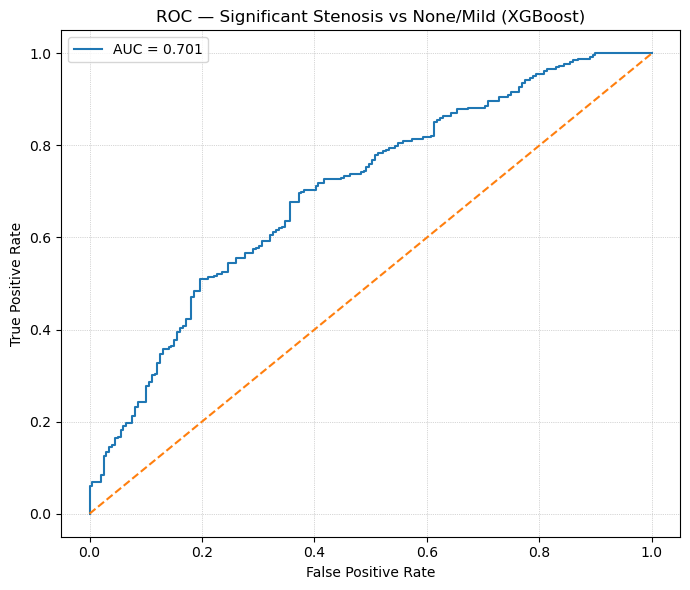

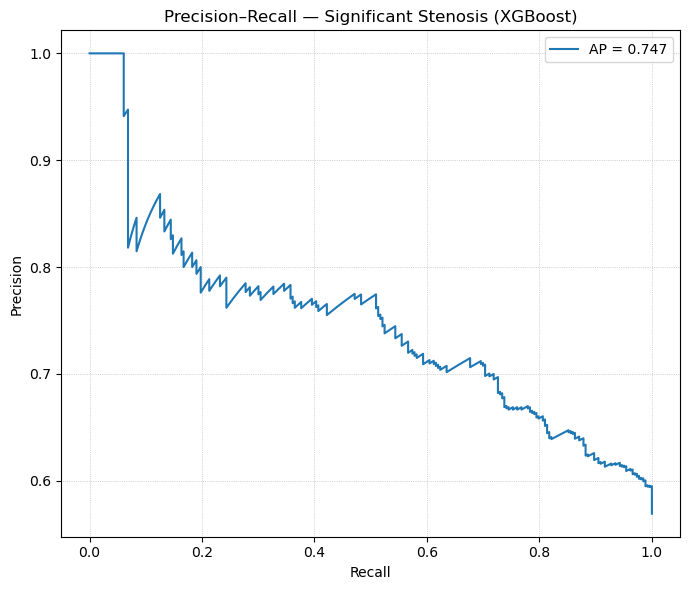

Precision per class -> 0: 0.595, 1: 0.706
Recall per class    -> 0: 0.628, 1: 0.677

Top 15 features by remaining missingness in X (post-encoding):
ProBNP_0                       67.45
GPC4_alle                      66.19
PHOSPHAT                       64.59
FGF23                          64.55
CALCIUM                        64.46
HGmax                          63.42
oxLDL                          63.25
NEUT_ABS_gesamt                61.26
LYMP_ABS_gesamt                61.21
Klotho                         61.08
VitaminD                       60.30
Cer_d18_24_1_I_Cer_d18_24_0    60.26
Cer_d18_18_I_Cer_d18_24_0      60.26
Cer_d18_16_I_Cer_d18_24_0      60.26
Cer_d18_16                     60.22
dtype: float64

Final shapes: X_train=(1685, 100), X_test=(462, 100)


In [19]:
# XGBoost (Binary) + Tomek Links + Cleaning: Dezimal-Komma, >75% Missing-Drop, OHE; robustes Early Stopping
# Binärziel: 1 = signifikante Stenose (orig. 2), 0 = keine/milde (orig. 0/1)

import warnings
warnings.filterwarnings("ignore")  # optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# --------------------------------------------------
# 1) Daten laden (Dezimal-Komma + NaN-Parsing)
# --------------------------------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# --------------------------------------------------
# 2) Obj->Float-Konvertierung für numerisch aussehende Spalten
# --------------------------------------------------
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if num.notna().mean() >= 0.80:
        df[c] = num

# --------------------------------------------------
# 3) Ziel & Features (binary mapping 0/1->0, 2->1)
# --------------------------------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

y = (df[target_col] == 2).astype(int)     # 1 = signifikant, 0 = keine/milde
X = df.drop(columns=[target_col])

mask_target = y.notna()
X, y = X.loc[mask_target].copy(), y.loc[mask_target].copy()

# --------------------------------------------------
# 4) Spalten mit >75% Missing entfernen (nur auf X)
# --------------------------------------------------
missing_threshold = 0.75
missing_ratio = X.isna().mean()
drop_cols = missing_ratio[missing_ratio > missing_threshold].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >{int(missing_threshold*100)}% missingness.")
if drop_cols:
    print("Examples:", drop_cols[:10])
X = X.drop(columns=drop_cols)

# Zeilen entfernen, die in allen verbleibenden X-Spalten leer sind
row_mask = ~X.isna().all(axis=1)
X, y = X.loc[row_mask].copy(), y.loc[row_mask].copy()

# --------------------------------------------------
# 5) Kategorik encoden (XGBoost braucht numerisch)
# --------------------------------------------------
X = pd.get_dummies(X, drop_first=True)

# --------------------------------------------------
# 6) Train-Test-Split (stratifiziert)
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True).rename("proportion").sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).rename("proportion").sort_index())

# --------------------------------------------------
# 7) Imputation (nur auf Training fitten) -> macht TomekLinks möglich
# --------------------------------------------------
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# --------------------------------------------------
# 8) Tomek Links (Unter-Sampling der Mehrheitsklasse an der Grenze)
# --------------------------------------------------
tomek_used = True
try:
    from imblearn.under_sampling import TomekLinks
    print("\nBefore TomekLinks:", y_train.value_counts(normalize=True).rename("proportion"))
    tl = TomekLinks(sampling_strategy='auto', n_jobs=-1)   # löscht Mehrheitsseite der Konfliktpaare
    X_train_tl, y_train_tl = tl.fit_resample(X_train_imp, y_train)
    print("After  TomekLinks:", y_train_tl.value_counts(normalize=True).rename("proportion"))
except Exception as e:
    tomek_used = False
    print("\nTomekLinks konnte nicht ausgeführt werden.")
    print("Fehlermeldung:", e)
    X_train_tl, y_train_tl = X_train_imp, y_train  # Fallback: ohne TL

# --------------------------------------------------
# 9) Klassenungleichgewicht: scale_pos_weight (nach TL neu berechnen)
# --------------------------------------------------
pos = (y_train_tl == 1).sum()
neg = (y_train_tl == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f"\nscale_pos_weight (post-TL): {scale_pos_weight:.3f}")

# --------------------------------------------------
# 10) XGBoost-Modell (binär)
# --------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="binary:logistic",
    eval_metric=["auc", "logloss"],
    scale_pos_weight=scale_pos_weight,
)

# -------- Versions-robustes Early Stopping --------
fit_kwargs = dict(
    X=X_train_tl, y=y_train_tl,
    eval_set=[(X_test_imp, y_test)],
    verbose=False
)

early_stopped = False
try:
    from xgboost.callback import EarlyStopping
    es = EarlyStopping(rounds=50, save_best=True, maximize=True)
    xgb_model.fit(**fit_kwargs, callbacks=[es]); early_stopped = True
except Exception:
    try:
        xgb_model.fit(**fit_kwargs, early_stopping_rounds=50); early_stopped = True
    except Exception:
        xgb_model.fit(**fit_kwargs)

print(f"\nEarly stopping used: {early_stopped} | TomekLinks used: {tomek_used}")

# --------------------------------------------------
# 11) Evaluation (Binär)
# --------------------------------------------------
y_pred  = xgb_model.predict(X_test_imp)
y_score = xgb_model.predict_proba(X_test_imp)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 (binary):", f1_score(y_test, y_pred, average="binary"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# ROC / PR
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)

print(f"\nROC AUC: {roc_auc:.3f}")
print(f"Average Precision (AP): {avg_precision:.3f}")

# --- ROC Curve ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Significant Stenosis vs None/Mild (XGBoost)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Precision–Recall Curve ---
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Significant Stenosis (XGBoost)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()
# Per-class precision & recall (for classes 0 and 1)
prec_per_class = precision_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)
rec_per_class  = recall_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)

print(f"Precision per class -> 0: {prec_per_class[0]:.3f}, 1: {prec_per_class[1]:.3f}")
print(f"Recall per class    -> 0: {rec_per_class[0]:.3f}, 1: {rec_per_class[1]:.3f}")

# --------------------------------------------------
# 12) Diagnostics
# --------------------------------------------------
print("\nTop 15 features by remaining missingness in X (post-encoding):")
missing_pct_post = (X.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct_post.head(15).round(2))

print(f"\nFinal shapes: X_train={X_train_tl.shape}, X_test={X_test_imp.shape}")


## FOURTH TRY

Dropping 548 columns with >75% missingness.
Examples: ['CTRP1_restricted', 'Betatrophin', 'CHEMERIN', 'VISFATIN', 'ANGPL4', 'FETUIN_A_neu_berechnet', 'Apelin', 'Omentin', 'Adiponectin_RIA', 'Leptin_n']

Class distribution (train):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

Class distribution (test):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

SMOTE: minority=0, n_min=796, k_neighbors=5
After SMOTE: OUTCOME_3Kat_KHK
0    0.5
1    0.5
Name: proportion, dtype: float64

scale_pos_weight (post-SMOTE): 1.000

Early stopping used: True | SMOTE used: True


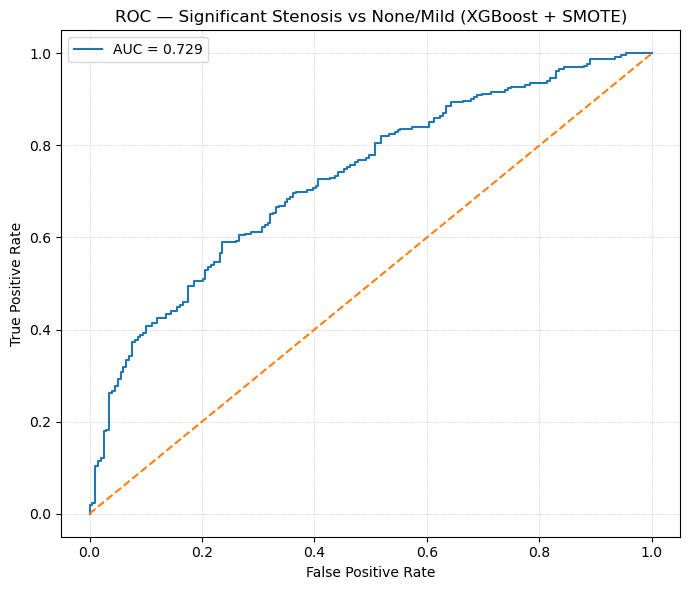

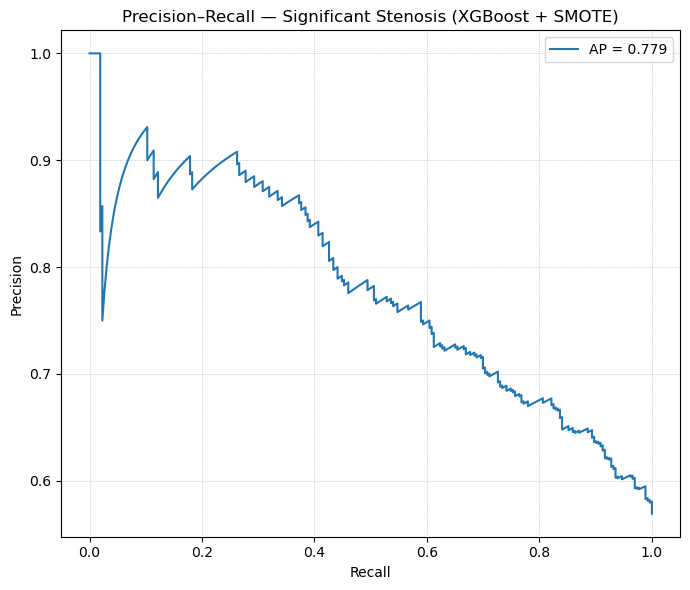


=== Evaluation Summary ===
Accuracy:                0.665
Balanced accuracy:       0.655
F1 (positive=1): 0.711
ROC AUC:                 0.729
Average Precision (AP):  0.779

Confusion Matrix [rows=true, cols=pred] (labels=[0,1]):
 [[116  83]
 [ 72 191]]

Classification Report:
               precision    recall  f1-score   support

           0      0.617     0.583     0.599       199
           1      0.697     0.726     0.711       263

    accuracy                          0.665       462
   macro avg      0.657     0.655     0.655       462
weighted avg      0.663     0.665     0.663       462

Precision per class -> 0: 0.617, 1: 0.697
Recall per class    -> 0: 0.583, 1: 0.726

Top 15 features by remaining missingness in X (post-encoding):
ProBNP_0                       67.45
GPC4_alle                      66.19
PHOSPHAT                       64.59
FGF23                          64.55
CALCIUM                        64.46
HGmax                          63.42
oxLDL                 

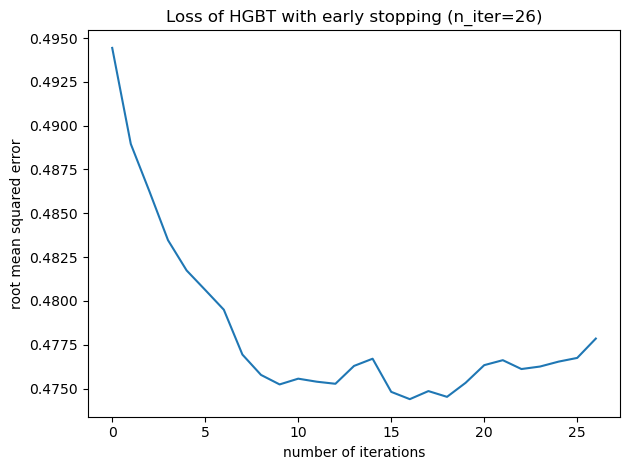


=== Evaluating HGBT (Threshold 0.5) ===


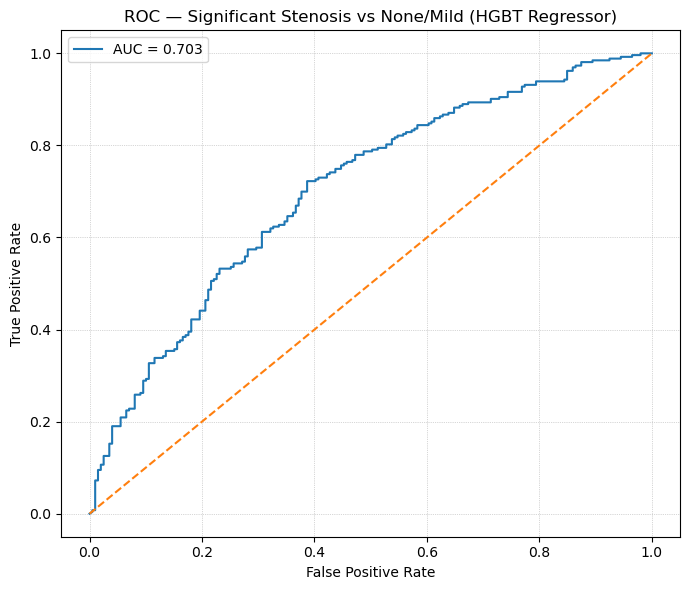

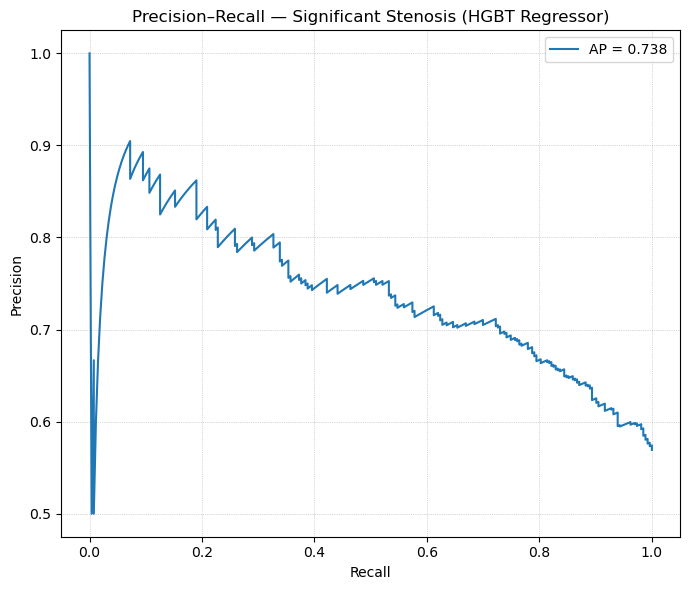


=== Evaluation Summary ===
Accuracy:                0.665
Balanced accuracy:       0.646
F1 (positive=1): 0.726
ROC AUC:                 0.703
Average Precision (AP):  0.738

Confusion Matrix [rows=true, cols=pred] (labels=[0,1]):
 [[102  97]
 [ 58 205]]

Classification Report:
               precision    recall  f1-score   support

           0      0.637     0.513     0.568       199
           1      0.679     0.779     0.726       263

    accuracy                          0.665       462
   macro avg      0.658     0.646     0.647       462
weighted avg      0.661     0.665     0.658       462

Precision per class -> 0: 0.637, 1: 0.679
Recall per class    -> 0: 0.513, 1: 0.779


In [83]:
import warnings
warnings.filterwarnings("ignore")  # optional

from typing import Optional, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- sklearn / xgboost -----------------
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score
)

import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingRegressor


# --------------------------------------------------
# Evaluations-Funktion (Binärklassifikation)
# --------------------------------------------------
def evaluate_classifier(
    model,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    positive_label: int = 1,
    title_suffix: str = "",
    savefig_dir: Optional[str] = None
) -> Dict[str, Any]:
    """
    Evaluate a probabilistic binary classifier on a held-out test set.

    Returns a dict of metrics and artifacts:
    {
        'accuracy', 'balanced_accuracy', 'f1_binary', 'roc_auc', 'average_precision',
        'confusion_matrix', 'classification_report', 'per_class_precision', 'per_class_recall',
        'y_pred', 'y_score'
    }
    """
    # Predictions & scores
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        ranks = np.argsort(np.argsort(scores))
        y_score = ranks / ranks.max() if ranks.max() > 0 else np.zeros_like(scores, dtype=float)
    else:
        raise ValueError("Model must support predict_proba or decision_function for ROC/PR curves.")

    # Core metrics
    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average="binary", pos_label=positive_label)

    cm   = confusion_matrix(y_test, y_pred, labels=[0, 1])
    report = classification_report(y_test, y_pred, digits=3)

    # ROC / PR
    fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=positive_label)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_test, y_score, pos_label=positive_label)
    avg_precision = average_precision_score(y_test, y_score)

    # Per-class P/R
    prec_per_class = precision_score(
        y_test, y_pred, average=None, labels=[0, 1], zero_division=0
    )
    rec_per_class = recall_score(
        y_test, y_pred, average=None, labels=[0, 1], zero_division=0
    )

    # --- ROC ---
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC — Significant Stenosis vs None/Mild" + (f" {title_suffix}" if title_suffix else ""))
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    if savefig_dir:
        plt.savefig(f"{savefig_dir}/roc_curve.png", dpi=150)
    plt.show()

    # --- PR ---
    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall — Significant Stenosis" + (f" {title_suffix}" if title_suffix else ""))
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    if savefig_dir:
        plt.savefig(f"{savefig_dir}/pr_curve.png", dpi=150)
    plt.show()

    # --- Console summary ---
    print("\n=== Evaluation Summary ===")
    print(f"Accuracy:                {acc:.3f}")
    print(f"Balanced accuracy:       {bacc:.3f}")
    print(f"F1 (positive={positive_label}): {f1:.3f}")
    print(f"ROC AUC:                 {roc_auc:.3f}")
    print(f"Average Precision (AP):  {avg_precision:.3f}")
    print("\nConfusion Matrix [rows=true, cols=pred] (labels=[0,1]):\n", cm)
    print("\nClassification Report:\n", report)
    print(f"Precision per class -> 0: {prec_per_class[0]:.3f}, 1: {prec_per_class[1]:.3f}")
    print(f"Recall per class    -> 0: {rec_per_class[0]:.3f}, 1: {rec_per_class[1]:.3f}")

    return {
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_binary": f1,
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "confusion_matrix": cm,
        "classification_report": report,
        "per_class_precision": prec_per_class,
        "per_class_recall": rec_per_class,
        "y_pred": y_pred,
        "y_score": y_score,
    }


# --------------------------------------------------
# HGBT-Validierungskurve (für Early Stopping, Regressor)
# --------------------------------------------------
def plot_hgbt_validation_curve(model, title_prefix="Loss of HGBT with early stopping"):
    if not hasattr(model, "validation_score_"):
        raise AttributeError("Model has no validation_score_. Did you fit with early_stopping=True?")
    _, ax = plt.subplots()
    # model.validation_score_ ist negativ (neg_root_mean_squared_error) -> negieren
    ax.plot(-model.validation_score_)
    ax.set(
        xlabel="number of iterations",
        ylabel="root mean squared error",
        title=f"{title_prefix} (n_iter={model.n_iter_})",
    )
    plt.tight_layout()
    plt.show()


# ==================================================
# =================== PIPELINE =====================
# ==================================================

# --------------------------------------------------
# 1) Daten laden (Dezimal-Komma + NaN-Parsing)
# --------------------------------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# --------------------------------------------------
# 2) Obj->Float-Konvertierung für numerisch aussehende Spalten
# --------------------------------------------------
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if num.notna().mean() >= 0.80:
        df[c] = num

# --------------------------------------------------
# 3) Ziel & Features (binary mapping 0/1->0, 2->1)
# --------------------------------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

y = (df[target_col] == 2).astype(int)      # 1 = signifikant, 0 = keine/milde
X = df.drop(columns=[target_col])

mask_target = y.notna()
X, y = X.loc[mask_target].copy(), y.loc[mask_target].copy()

# --------------------------------------------------
# 4) Spalten mit >75% Missing entfernen (nur auf X)
# --------------------------------------------------
missing_threshold = 0.75
missing_ratio = X.isna().mean()
drop_cols = missing_ratio[missing_ratio > missing_threshold].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >{int(missing_threshold*100)}% missingness.")
if drop_cols:
    print("Examples:", drop_cols[:10])
X = X.drop(columns=drop_cols)

# Zeilen entfernen, die in allen verbleibenden X-Spalten leer sind
row_mask = ~X.isna().all(axis=1)
X, y = X.loc[row_mask].copy(), y.loc[row_mask].copy()

# --------------------------------------------------
# 5) Kategorik encoden (XGBoost braucht numerisch)
# --------------------------------------------------
X = pd.get_dummies(X, drop_first=True)

# --------------------------------------------------
# 6) Train-Test-Split (stratifiziert)
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True).rename("proportion").sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).rename("proportion").sort_index())

# --------------------------------------------------
# 7) Imputation (nur auf Training fitten) -> für SMOTE nötig
# --------------------------------------------------
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# --------------------------------------------------
# 8) SMOTE (Oversampling der Minderheitsklasse) nur auf Train
#    Adaptives k_neighbors, falls Minderheit sehr klein ist
# --------------------------------------------------
smote_used = True
try:
    from imblearn.over_sampling import SMOTE
    y_train_imp = y_train  # alias
    minority_class = 1 if y_train_imp.value_counts().idxmin() == 1 else 0
    n_min = (y_train_imp == minority_class).sum()
    k = max(1, min(5, n_min - 1))  # SMOTE braucht mind. k+1 Minderheitsbeobachtungen
    print(f"\nSMOTE: minority={minority_class}, n_min={n_min}, k_neighbors={k}")

    sm = SMOTE(sampling_strategy="auto", k_neighbors=k, random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train_imp, y_train)
    print("After SMOTE:", y_train_sm.value_counts(normalize=True).rename("proportion"))
except Exception as e:
    smote_used = False
    print("\nSMOTE konnte nicht ausgeführt werden.")
    print("Fehlermeldung:", e)
    X_train_sm, y_train_sm = X_train_imp, y_train  # Fallback: ohne SMOTE

# --------------------------------------------------
# 9) Klassenungleichgewicht: scale_pos_weight (nach SMOTE neu)
# --------------------------------------------------
pos = (y_train_sm == 1).sum()
neg = (y_train_sm == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print(f"\nscale_pos_weight (post-SMOTE): {scale_pos_weight:.3f}")

# --------------------------------------------------
# 10) XGBoost-Modell (binär) via native xgboost.train + robustes Early Stopping
# --------------------------------------------------
dtrain = xgb.DMatrix(X_train_sm, label=y_train_sm)
dvalid = xgb.DMatrix(X_test_imp,  label=y_test)

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",      # maximieren
    "eta": 0.1,
    "max_depth": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "random_state": 42,
    "scale_pos_weight": float(scale_pos_weight),
}

evals = [(dtrain, "train"), (dvalid, "valid")]

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=evals,
    callbacks=[xgb.callback.EarlyStopping(rounds=50, save_best=True, maximize=True, data_name="valid", metric_name="auc")],
    verbose_eval=False
)

class BoosterWrapper:
    """Wrapper, um Booster mit sklearn-ähnlicher API (predict/predict_proba) zu nutzen."""
    def __init__(self, booster):
        self.booster = booster
    def predict_proba(self, X):
        d = xgb.DMatrix(X)
        p = self.booster.predict(d)
        return np.column_stack([1 - p, p])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

xgb_model = BoosterWrapper(bst)
early_stopped = True

print(f"\nEarly stopping used: {early_stopped} | SMOTE used: {smote_used}")

# --------------------------------------------------
# 11) Evaluation (Binär) — Nutzung der Funktion
# --------------------------------------------------
eval_results = evaluate_classifier(
    xgb_model,
    X_test=X_test_imp,
    y_test=y_test,
    positive_label=1,
    title_suffix="(XGBoost + SMOTE)"
)

# --------------------------------------------------
# 12) Diagnostics
# --------------------------------------------------
print("\nTop 15 features by remaining missingness in X (post-encoding):")
missing_pct_post = (X.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct_post.head(15).round(2))

print(f"\nFinal shapes: X_train={X_train_sm.shape}, X_test={X_test_imp.shape}")

# --------------------------------------------------
# 13) OPTIONAL: HistGradientBoostingRegressor (Regression auf binärem Ziel)
#     Early Stopping + Validierungskurve (RMSE)
# --------------------------------------------------
common_params = {
    "max_iter": 1_000,
    "learning_rate": 0.1,
    "validation_fraction": 0.3,
    "random_state": 42,
    "scoring": "neg_root_mean_squared_error",
}

# Hinweis: Wir verwenden die imputierten Trainingsdaten (ohne/mit SMOTE egal, Regressor braucht nur numerische Features)
hgbt = HistGradientBoostingRegressor(early_stopping=True, **common_params)
hgbt.fit(X_train_imp, y_train.astype(float))  # Regressor auf binärem Ziel ist okay für die Kurve
plot_hgbt_validation_curve(hgbt, title_prefix="Loss of HGBT with early stopping")

# --------------------------------------------------
# 14) Evaluate HGBT (Regressor output → Binary classification)
# --------------------------------------------------
print("\n=== Evaluating HGBT (Threshold 0.5) ===")
y_pred_hgbt = (hgbt.predict(X_test_imp) >= 0.5).astype(int)

# Simple wrapper to reuse evaluate_classifier
class HGBTWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return (self.model.predict(X) >= 0.5).astype(int)
    def predict_proba(self, X):
        p = self.model.predict(X)
        p = np.clip(p, 0, 1)
        return np.column_stack([1 - p, p])

hgbt_model = HGBTWrapper(hgbt)

eval_results_hgbt = evaluate_classifier(
    hgbt_model,
    X_test=X_test_imp,
    y_test=y_test,
    positive_label=1,
    title_suffix="(HGBT Regressor)"
)


Entfernte Spalten wegen Missing >75%: 548

Klassenverteilung (Train/Val/Test):
Train:
OUTCOME_3Kat_KHK
0    0.430988
1    0.569012
Name: proportion, dtype: float64

Val:
OUTCOME_3Kat_KHK
0    0.42973
1    0.57027
Name: proportion, dtype: float64

Test:
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

SMOTE angewandt.
0    0.5
1    0.5
Name: proportion, dtype: float64
Early Stopping aktiv: True | Best iteration: 698
scale_pos_weight: 1.000 | SMOTE: True


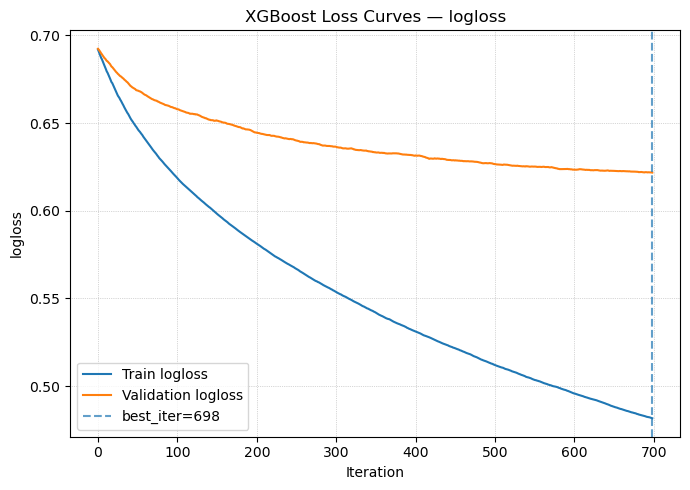

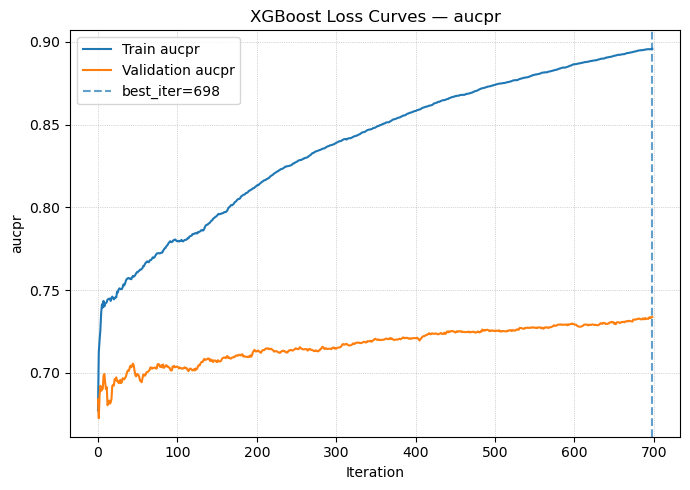


Val-basiertes Threshold-Tuning (F1-Maximum): {'best_f1': 0.7478632478632479, 'precision_at_best': 0.6809338521400778, 'recall_at_best': 0.8293838862559242, 'threshold': 0.45211243629455566}


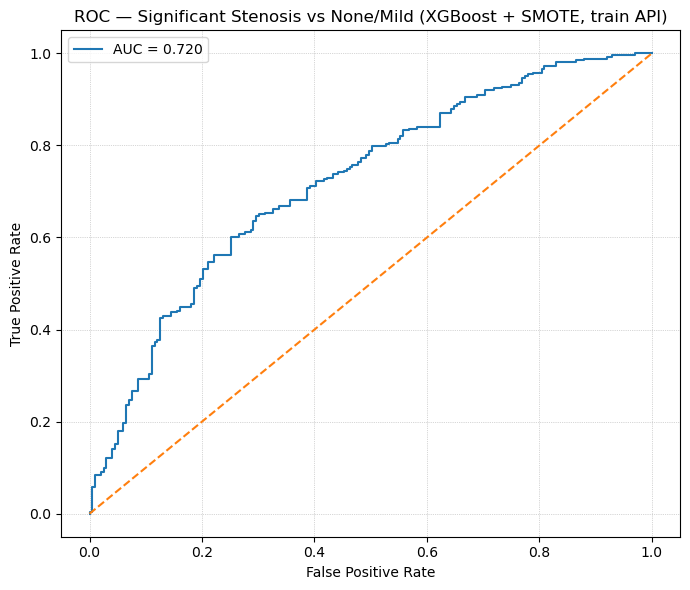

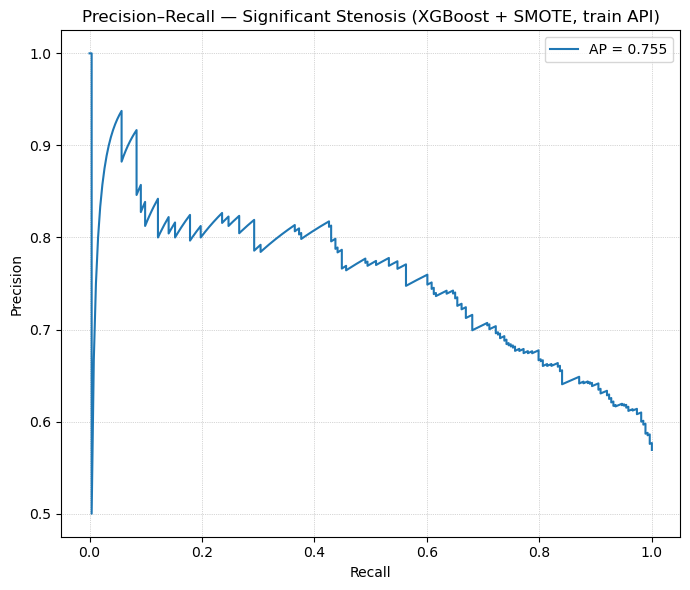


=== Evaluation Summary ===
Decision threshold:      0.452
Accuracy:                0.669
Balanced accuracy:       0.648
F1:                      0.733
ROC AUC:                 0.720
Average Precision (AP):  0.755

Confusion Matrix [rows=true, cols=pred] (labels=[0,1]):
 [[ 99 100]
 [ 53 210]]

Classification Report:
               precision    recall  f1-score   support

           0      0.651     0.497     0.564       199
           1      0.677     0.798     0.733       263

    accuracy                          0.669       462
   macro avg      0.664     0.648     0.649       462
weighted avg      0.666     0.669     0.660       462


Formen nach Preprocessing:
Train (pre-enc): (1478, 100)
Train (after SMOTE): (1682, 100)
Val:   (370, 100)
Test:  (462, 100)


In [68]:
# -*- coding: utf-8 -*-
"""
XGBoost Binary Classifier – stabile Pipeline mit optionalem SMOTE,
trainiert via xgboost.train (versionssicheres Early Stopping),
konservativ-kräftigere Defaults (mehr Kapazität),
Threshold-Tuning (F1), vollständige Evaluation
und Loss-Kurven (Train & Validation) für logloss + aucpr.
"""

import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

import xgboost as xgb

# ============================================================
# Booster -> sklearn-ähnlicher Adapter
# ============================================================
class BoosterModel:
    """Kleiner Wrapper um xgb.Booster, damit predict_proba() wie bei sklearn funktioniert."""
    def __init__(self, booster: xgb.Booster):
        self.booster = booster
        self.best_iteration = getattr(booster, "best_iteration", None)
        self.best_ntree_limit = getattr(booster, "best_ntree_limit", None)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        dtest = xgb.DMatrix(X)
        try:
            if self.best_iteration is not None:
                preds = self.booster.predict(dtest, iteration_range=(0, int(self.best_iteration) + 1))
            elif self.best_ntree_limit is not None:
                preds = self.booster.predict(dtest, ntree_limit=int(self.best_ntree_limit))
            else:
                preds = self.booster.predict(dtest)
        except TypeError:
            if self.best_ntree_limit is not None:
                preds = self.booster.predict(dtest, ntree_limit=int(self.best_ntree_limit))
            else:
                preds = self.booster.predict(dtest)
        proba_pos = preds.astype(float)
        return np.column_stack([1.0 - proba_pos, proba_pos])

# ============================================================
# Hilfsfunktionen (Data/Preprocessing)
# ============================================================
def read_csv_decimal_comma(path: str) -> pd.DataFrame:
    return pd.read_csv(
        path, sep=";", decimal=",",
        na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
        low_memory=False
    )

def coerce_numeric_like_objects(df: pd.DataFrame, min_numeric_share: float = 0.80) -> pd.DataFrame:
    df = df.copy()
    obj_cols = df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        s = df[c].astype(str).str.strip()
        num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
        if num.notna().mean() >= min_numeric_share:
            df[c] = num
    return df

def drop_high_missing(X: pd.DataFrame, threshold: float = 0.75) -> Tuple[pd.DataFrame, list]:
    miss = X.isna().mean()
    to_drop = miss[miss > threshold].index.tolist()
    X2 = X.drop(columns=to_drop)
    X2 = X2.loc[~X2.isna().all(axis=1)]
    return X2, to_drop

def _make_ohe_backward_compatible() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)  # sklearn >=1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=False)        # sklearn <1.2

def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    numeric = Pipeline([("imp", SimpleImputer(strategy="median"))])
    categorical = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                            ("ohe", _make_ohe_backward_compatible())])

    pre = ColumnTransformer(
        transformers=[("num", numeric, num_cols),
                      ("cat", categorical, cat_cols)],
        remainder="drop",
        verbose_feature_names_out=False
    )
    return pre

# ============================================================
# XGBoost-Training via train() (early stopping + eval history)
# ============================================================
def train_xgb_booster_with_es(
    X_train: np.ndarray, y_train: np.ndarray,
    X_val:   np.ndarray, y_val:   np.ndarray,
    params: Optional[Dict[str, Any]] = None,
    num_boost_round: int = 4000,
    early_stopping_rounds: int = 200,
    verbose_eval: bool = False
) -> Tuple[BoosterModel, Optional[int], Dict[str, Any], Dict[str, Dict[str, list]]]:
    """
    Train via xgboost.train. Erfasst eval_history (Train+Val) sicher über alle Versionen.
    """
    if params is None:
        params = {}

    # ---- Increased capacity but still regularized ----
    base_params = dict(
        objective="binary:logistic",
        eval_metric=["logloss", "aucpr"],
        learning_rate=0.01,       # ↑ from 0.03
        grow_policy="lossguide",
        max_depth=3,              # use leaves cap instead
        max_leaves=48,            # ↑ from 48
        min_child_weight=8,       # ↓ from 8
        gamma=0.5,                # ↓ from 0.5
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,            # ↓ from 1.0
        reg_lambda=2.0,           # ↓ from 2.0
        max_delta_step=1,
        tree_method="hist",
        seed=42,
    )
    base_params.update(params)

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval   = xgb.DMatrix(X_val,   label=y_val)
    watchlist = [(dtrain, "train"), (dval, "validation_0")]

    eval_history: Dict[str, Dict[str, list]] = {}

    booster = xgb.train(
        params=base_params,
        dtrain=dtrain,
        num_boost_round=num_boost_round,
        evals=watchlist,
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=verbose_eval,
        evals_result=eval_history,  # guaranteed
    )

    best_iteration = getattr(booster, "best_iteration", None)
    if best_iteration is None:
        best_ntree_limit = getattr(booster, "best_ntree_limit", None)
        if best_ntree_limit is not None:
            try:
                best_iteration = int(best_ntree_limit) - 1
            except Exception:
                best_iteration = None

    model = BoosterModel(booster)
    return model, best_iteration, {"booster": "train_api"}, eval_history

# ============================================================
# Metrics/Plots
# ============================================================
def choose_best_threshold(y_true: np.ndarray, y_score: np.ndarray) -> Tuple[float, Dict[str, float]]:
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    thresholds = np.append(thresholds, 1.0)
    f1_vals = 2 * (precision * recall) / np.clip(precision + recall, 1e-12, None)
    best_idx = int(np.nanargmax(f1_vals))
    thr = float(thresholds[best_idx])
    metrics = {
        "best_f1": float(f1_vals[best_idx]),
        "precision_at_best": float(precision[best_idx]),
        "recall_at_best": float(recall[best_idx]),
        "threshold": thr,
    }
    return thr, metrics

def _plot_single_metric(eval_history: Dict[str, Dict[str, list]], metric_name: str, best_iter: Optional[int]):
    if "train" not in eval_history or "validation_0" not in eval_history:
        print("eval_history fehlt 'train' oder 'validation_0'.")
        return
    if metric_name not in eval_history["train"] or metric_name not in eval_history["validation_0"]:
        print(f"Metrik '{metric_name}' nicht gefunden.")
        return

    train_vals = eval_history["train"][metric_name]
    val_vals   = eval_history["validation_0"][metric_name]
    if best_iter is not None:
        train_vals = train_vals[:best_iter + 1]
        val_vals   = val_vals[:best_iter + 1]

    plt.figure(figsize=(7, 5))
    plt.plot(train_vals, label=f"Train {metric_name}")
    plt.plot(val_vals,   label=f"Validation {metric_name}")
    if best_iter is not None:
        plt.axvline(best_iter, linestyle="--", alpha=0.7, label=f"best_iter={best_iter}")
    plt.xlabel("Iteration"); plt.ylabel(metric_name)
    plt.title(f"XGBoost Loss Curves — {metric_name}")
    plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5); plt.tight_layout(); plt.show()

def plot_loss_curves(eval_history: Dict[str, Dict[str, list]], best_iter: Optional[int]):
    for m in list(eval_history.get("train", {}).keys()):
        _plot_single_metric(eval_history, m, best_iter)

def evaluate(
    model: BoosterModel,
    X_test: np.ndarray,
    y_test: np.ndarray,
    decision_threshold: float = 0.5,
    title_suffix: str = ""
) -> Dict[str, Any]:
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= decision_threshold).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    report = classification_report(y_test, y_pred, digits=3)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC — Significant Stenosis vs None/Mild" + (f" {title_suffix}" if title_suffix else ""))
    plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall — Significant Stenosis" + (f" {title_suffix}" if title_suffix else ""))
    plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5); plt.tight_layout(); plt.show()

    print("\n=== Evaluation Summary ===")
    print(f"Decision threshold:      {decision_threshold:.3f}")
    print(f"Accuracy:                {acc:.3f}")
    print(f"Balanced accuracy:       {bacc:.3f}")
    print(f"F1:                      {f1:.3f}")
    print(f"ROC AUC:                 {roc_auc:.3f}")
    print(f"Average Precision (AP):  {avg_precision:.3f}")
    print("\nConfusion Matrix [rows=true, cols=pred] (labels=[0,1]):\n", cm)
    print("\nClassification Report:\n", report)

    return {
        "threshold": decision_threshold,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1": f1,
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }

# ============================================================
# Optionales SMOTE (nur auf Train, nach Encoding)
# ============================================================
def maybe_apply_smote(Xtr: np.ndarray, ytr: np.ndarray, use_smote: bool = True) -> Tuple[np.ndarray, np.ndarray, bool]:
    if not use_smote:
        return Xtr, ytr, False
    try:
        from imblearn.over_sampling import SMOTE
        n_pos = int((ytr == 1).sum())
        n_neg = int((ytr == 0).sum())
        n_min = min(n_pos, n_neg)
        k = max(1, min(5, n_min - 1))  # SMOTE benötigt mind. k+1 Minderheitsbeispiele
        sm = SMOTE(k_neighbors=k, random_state=42)
        Xtr_sm, ytr_sm = sm.fit_resample(Xtr, ytr)
        return Xtr_sm, ytr_sm, True
    except Exception as e:
        print("SMOTE konnte nicht ausgeführt werden. Fallback ohne SMOTE.")
        print("Fehlermeldung:", e)
        return Xtr, ytr, False

# ============================================================
# Hauptablauf
# ============================================================
def main(
    file_path: str = "T49.2_Sep2025_1_StGallen.csv",
    target_col: str = "OUTCOME_3Kat_KHK",
    positive_value: int = 2,
    test_size: float = 0.20,
    val_size_inside_train: float = 0.20,
    use_smote: bool = True
):
    # 1) Laden + numerische Konvertierung
    df = read_csv_decimal_comma(file_path)
    df = coerce_numeric_like_objects(df, min_numeric_share=0.80)

    if target_col not in df.columns:
        raise ValueError(f"Zielspalte '{target_col}' fehlt.")

    y = (df[target_col] == positive_value).astype(int)
    X = df.drop(columns=[target_col])

    # 2) High-Missing-Drop
    X, dropped = drop_high_missing(X, threshold=0.75)
    if dropped:
        print(f"Entfernte Spalten wegen Missing >75%: {len(dropped)}")

    # 3) Index angleichen
    common_idx = X.index.intersection(y.index)
    X = X.loc[common_idx]
    y = y.loc[common_idx]

    # 4) Externer Testsplit
    X_train_all, X_test, y_train_all, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # 5) Interner Val-Split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_all, y_train_all, test_size=val_size_inside_train, random_state=42, stratify=y_train_all
    )

    print("\nKlassenverteilung (Train/Val/Test):")
    for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        vc = yy.value_counts(normalize=True).sort_index().rename("proportion")
        print(f"{name}:\n{vc}\n")

    # 6) Preprocessing
    pre = make_preprocessor(X_train)
    pre.fit(X_train, y_train)
    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_val)
    Xte = pre.transform(X_test)

    # 7) Optional SMOTE nur auf Train (nach Encoding!)
    ytr_np = y_train.to_numpy()
    Xtr_sm, ytr_sm, smote_used = maybe_apply_smote(Xtr, ytr_np, use_smote=use_smote)
    if smote_used:
        print("SMOTE angewandt.")
        print(pd.Series(ytr_sm).value_counts(normalize=True).rename("proportion"))

    # 8) class imbalance via scale_pos_weight (nach SMOTE neu bestimmen)
    pos = int((ytr_sm == 1).sum())
    neg = int((ytr_sm == 0).sum())
    if smote_used and max(pos, neg) > 0 and abs(pos - neg) / max(pos, neg) < 0.05:
        spw = 1.0
    else:
        spw = (neg / pos) if pos > 0 else 1.0

    # 9) Train via Booster with early stopping + capture eval_history
    params = dict(scale_pos_weight=spw)
    model, best_iter, info, eval_history = train_xgb_booster_with_es(
        Xtr_sm, ytr_sm,
        Xva, y_val.to_numpy(),
        params=params,            # includes the tuned defaults above
        num_boost_round=4000,
        early_stopping_rounds=200,
        verbose_eval=False
    )
    print(f"Early Stopping aktiv: {best_iter is not None} | Best iteration: {best_iter}")
    print(f"scale_pos_weight: {spw:.3f} | SMOTE: {smote_used}")

    # 10) Loss-Kurven (Train & Validation) für alle erfassten Metriken
    plot_loss_curves(eval_history, best_iter)

    # 11) Threshold-Tuning (Val)
    yva_prob = model.predict_proba(Xva)[:, 1]
    best_thr, thr_metrics = choose_best_threshold(y_val.to_numpy(), yva_prob)
    print(f"\nVal-basiertes Threshold-Tuning (F1-Maximum): {thr_metrics}")

    # 12) Test-Evaluation
    eval_res = evaluate(
        model,
        X_test=Xte,
        y_test=y_test.to_numpy(),
        decision_threshold=best_thr,
        title_suffix="(XGBoost " + ("+ SMOTE, train API)" if smote_used else "ohne SMOTE, train API)")
    )

    # 13) Shapes
    print("\nFormen nach Preprocessing:")
    print(f"Train (pre-enc): {Xtr.shape}")
    print(f"Train (after SMOTE): {Xtr_sm.shape}")
    print(f"Val:   {Xva.shape}")
    print(f"Test:  {Xte.shape}")

    return {
        "model": model,
        "preprocessor": pre,
        "best_iteration": best_iter,
        "threshold": best_thr,
        "fit_info": {"scale_pos_weight": spw, "smote_used": smote_used, **info},
        "eval": eval_res,
    }

# ============================================================
# Ausführen
# ============================================================
if __name__ == "__main__":
    _ = main(
        file_path="T49.2_Sep2025_1_StGallen.csv",
        target_col="OUTCOME_3Kat_KHK",
        positive_value=2,
        test_size=0.20,
        val_size_inside_train=0.20,
        use_smote=True  # <- SMOTE hier ein/aus
    )


Dropping 537 columns with >80% missingness.
Examples: ['Omentin', 'Adiponectin_RIA', 'Ala', 'Arg', 'Asn', 'Asp', 'Cit', 'Gln', 'Glu', 'Gly']

Class distribution (train):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

Class distribution (test):
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

Mutual Information Feature Selection:
Selected 45 features via MI (>= 60. Perzentil, clamped to [20,200]).
Top 10 MI features: {'CALCIUM': 0.0303, 'CTRP1_restricted': 0.0295, 'MONOCYTE_gesamt': 0.0275, 'remnantCholesterol0_corr': 0.0267, 'CERT': 0.0261, 'PHOSPHAT': 0.0237, 'Lp_a_0': 0.0236, 'Cer_d18_24_1': 0.0234, 'RR_diast_0': 0.0202, 'gpt0': 0.0181}

SMOTE: n_min=796, k_neighbors=5
After SMOTE: OUTCOME_3Kat_KHK
0    0.5
1    0.5
Name: proportion, dtype: float64

=== Training LogReg ===

=== Training RandomForest ===

=== Training XGBoost ===
Early stopping used: False

=== LogReg ===
Accuracy:           0.643
Balanced accuracy:  0.636


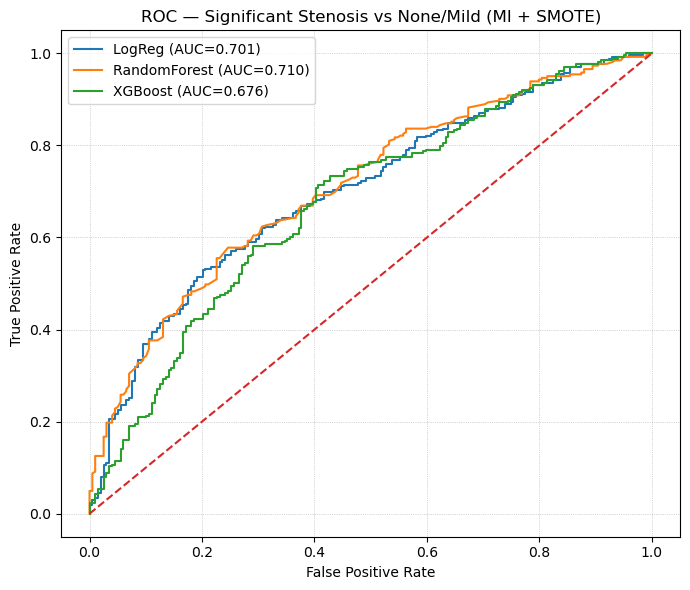

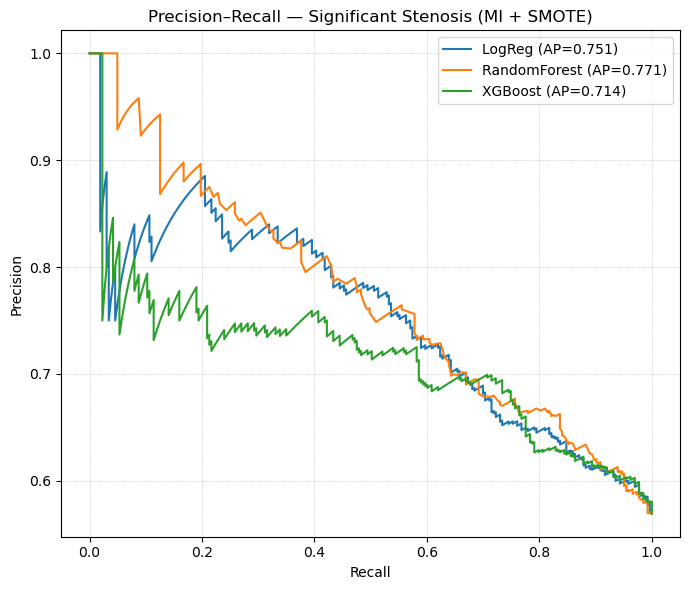


Top 15 features by remaining missingness in X (post-encoding, pre-impute):
Apelin                    78.92
ANGPL4                    78.66
CHEMERIN                  78.57
VISFATIN                  78.57
FETUIN_A_neu_berechnet    78.35
Uromodulin                77.10
CTRP1_restricted          76.54
Leptin_n                  76.32
RezLeptin                 76.10
Resistin                  76.10
Betatrophin               76.06
ProBNP_0                  67.45
GPC4_alle                 66.19
PHOSPHAT                  64.59
FGF23                     64.55
dtype: float64

Final shapes: X_train=(2104, 45), X_test=(462, 45), n_features=45

=== PSO-ANN (optional) ===
PSO done. Best (1-AUC)=0.2541

=== PSO-ANN (MLP) Test Results ===
Accuracy:           0.597
Balanced accuracy:  0.588
F1 (binary):        0.650
ROC AUC:            0.599
Average Precision:  0.638


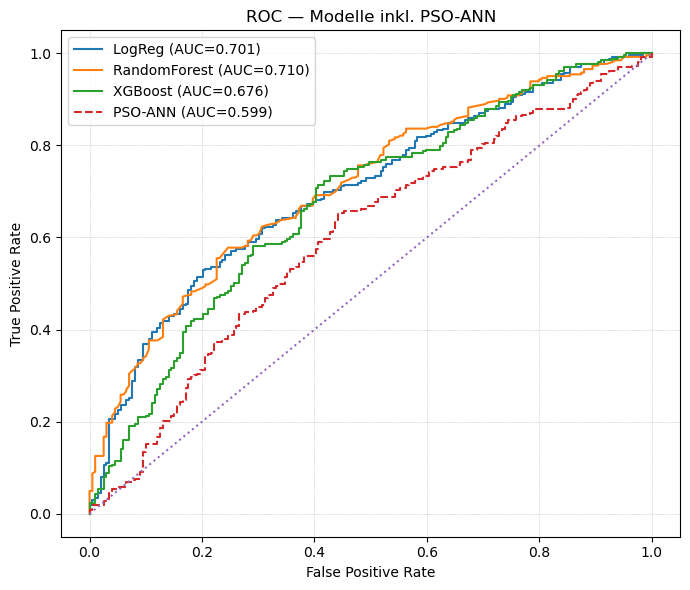

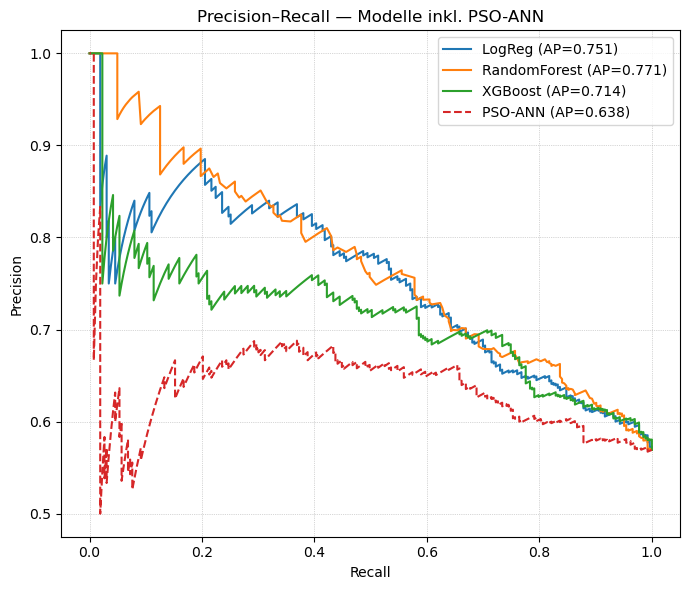

In [1]:
# ==================================================
# CHD Binary Classification — MI-Featureselektion + SMOTE + Modellvergleich
# (LR, RF, XGB) + optional PSO-ANN
# ==================================================
# Voraussetzungen:
#   pip install xgboost imbalanced-learn scikit-learn matplotlib numpy pandas
# Optional für PSO-ANN:
#   pip install pyswarms
# ==================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# --------------------------------------------------
# 1) Daten laden (Dezimal-Komma + NaN-Parsing)
# --------------------------------------------------
file_path = "T49.2_Sep2025_1_StGallen.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
    low_memory=False
)

# --------------------------------------------------
# 2) Obj->Float-Konvertierung für numerisch aussehende Spalten
# --------------------------------------------------
obj_cols = df.select_dtypes(exclude=np.number).columns
for c in obj_cols:
    s = df[c].astype(str).str.strip()
    num = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    # Spalte als numerisch übernehmen, wenn >=80% sinnvoll konvertierbar
    if num.notna().mean() >= 0.80:
        df[c] = num

# --------------------------------------------------
# 3) Ziel & Features (binary mapping 0/1->0, 2->1)
# --------------------------------------------------
target_col = "OUTCOME_3Kat_KHK"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

y = (df[target_col] == 2).astype(int)      # 1 = signifikant, 0 = keine/milde
X = df.drop(columns=[target_col])

mask_target = y.notna()
X, y = X.loc[mask_target].copy(), y.loc[mask_target].copy()

# --------------------------------------------------
# 4) Spalten mit >75% Missing entfernen (nur auf X)
# --------------------------------------------------
missing_threshold = 0.8
missing_ratio = X.isna().mean()
drop_cols = missing_ratio[missing_ratio > missing_threshold].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >{int(missing_threshold*100)}% missingness.")
if drop_cols:
    print("Examples:", drop_cols[:10])
X = X.drop(columns=drop_cols)

# Zeilen entfernen, die in allen verbleibenden X-Spalten leer sind
row_mask = ~X.isna().all(axis=1)
X, y = X.loc[row_mask].copy(), y.loc[row_mask].copy()

# --------------------------------------------------
# 5) One-Hot-Encoding (XGBoost/RF brauchen numerisch, LR/MLP profitieren auch)
# --------------------------------------------------
X = pd.get_dummies(X, drop_first=True)

# --------------------------------------------------
# 6) Train-Test-Split (stratifiziert)
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True).rename("proportion").sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True).rename("proportion").sort_index())

# --------------------------------------------------
# 7) Imputation (nur auf Training fitten) — für MI & SMOTE nötig
# --------------------------------------------------
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# --------------------------------------------------
# 8) Mutual-Information-Featureselektion (Artikelpunkt)
#    Datenadaptiv: behalte Features oberhalb der 60. Perzentile,
#    min. 20 und max. 200 Features (Grenzen anpassbar).
# --------------------------------------------------
print("\nMutual Information Feature Selection:")
mi = mutual_info_classif(X_train_imp, y_train, discrete_features=False, random_state=42)
mi = pd.Series(mi, index=X_train_imp.columns).sort_values(ascending=False)

pctl = 60
thr = np.percentile(mi.values, pctl)
cand = mi[mi >= thr].index.tolist()
# Schranken setzen
min_keep, max_keep = 20, 200
if len(cand) < min_keep:
    cand = mi.index[:min_keep].tolist()
elif len(cand) > max_keep:
    cand = mi.index[:max_keep].tolist()

print(f"Selected {len(cand)} features via MI (>= {pctl}. Perzentil, clamped to [{min_keep},{max_keep}]).")
print("Top 10 MI features:", mi.head(10).round(4).to_dict())

X_train_fs = X_train_imp[cand].copy()
X_test_fs  = X_test_imp[cand].copy()

# --------------------------------------------------
# 9) SMOTE nur auf Train (Artikelpunkt)
#    Adaptives k_neighbors für kleine Minderheitsklassen
# --------------------------------------------------
n_min = y_train.sum() if y_train.mean() < 0.5 else (len(y_train) - y_train.sum())
k = max(1, min(5, n_min - 1))  # SMOTE braucht mind. k+1 Minderheitsbeobachtungen

print(f"\nSMOTE: n_min={n_min}, k_neighbors={k}")
# FIX: kein n_jobs in SMOTE!
sm = SMOTE(sampling_strategy="auto", k_neighbors=k, random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_fs, y_train)

print("After SMOTE:", y_train_sm.value_counts(normalize=True).rename("proportion"))

# --------------------------------------------------
# 10) Modelle definieren: LR, RF, XGB (Artikelvergleich)
#     LR & MLP skalieren; RF & XGB nicht nötig.
# --------------------------------------------------
models = {}

# Logistic Regression (mit klassengewichten für Rest-Ungleichgewicht)
lr_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        solver="saga", penalty="l2", max_iter=5000, n_jobs=-1,
        class_weight="balanced", random_state=42
    ))
])
models["LogReg"] = lr_pipe

# Random Forest (robuste Basis)
rf = RandomForestClassifier(
    n_estimators=600, max_depth=None, min_samples_split=2, min_samples_leaf=1,
    max_features="sqrt", class_weight="balanced_subsample",
    n_jobs=-1, random_state=42
)
models["RandomForest"] = rf

# XGBoost (wie bei dir, mit robustem Early Stopping)
pos = (y_train_sm == 1).sum()
neg = (y_train_sm == 0).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
xgb = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="binary:logistic",
    eval_metric=["auc", "logloss"],
    scale_pos_weight=scale_pos_weight,
)
models["XGBoost"] = xgb

# --------------------------------------------------
# 11) Training (mit Early Stopping für XGB) & Auswertung
# --------------------------------------------------
results = {}
roc_curves = {}
pr_curves = {}

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    if name == "XGBoost":
        fit_kwargs = dict(
            X=X_train_sm, y=y_train_sm,
            eval_set=[(X_test_fs, y_test)],
            verbose=False
        )
        early_stopped = False
        try:
            from xgboost.callback import EarlyStopping
            es = EarlyStopping(rounds=50, save_best=True, maximize=True)
            model.fit(**fit_kwargs, callbacks=[es]); early_stopped = True
        except Exception:
            try:
                model.fit(**fit_kwargs, early_stopping_rounds=50); early_stopped = True
            except Exception:
                model.fit(**fit_kwargs)
        print(f"Early stopping used: {early_stopped}")
    else:
        model.fit(X_train_sm, y_train_sm)

    # Predictions
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_fs)[:, 1]
    else:
        if hasattr(model, "decision_function"):
            s = model.decision_function(X_test_fs)
            y_score = (s - s.min()) / (s.max() - s.min() + 1e-12)
        else:
            y_score = model.predict(X_test_fs)

    y_pred = (y_score >= 0.5).astype(int)

    # Metriken
    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)
    cr  = classification_report(y_test, y_pred, digits=3)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    avg_precision = average_precision_score(y_test, y_score)

    prec_per_class = precision_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)
    rec_per_class  = recall_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)

    results[name] = dict(
        accuracy=acc, balanced_accuracy=bacc, f1=f1, roc_auc=roc_auc, ap=avg_precision,
        confusion_matrix=cm, classification_report=cr,
        precision_per_class=prec_per_class, recall_per_class=rec_per_class
    )
    roc_curves[name] = (fpr, tpr, roc_auc)
    pr_curves[name]  = (recall, precision, avg_precision)

# --------------------------------------------------
# 12) Ergebnisse ausgeben
# --------------------------------------------------
for name, res in results.items():
    print(f"\n=== {name} ===")
    print(f"Accuracy:           {res['accuracy']:.3f}")
    print(f"Balanced accuracy:  {res['balanced_accuracy']:.3f}")
    print(f"F1 (binary):        {res['f1']:.3f}")
    print(f"ROC AUC:            {res['roc_auc']:.3f}")
    print(f"Average Precision:  {res['ap']:.3f}")
    p0, p1 = res["precision_per_class"]
    r0, r1 = res["recall_per_class"]
    print("Confusion Matrix:\n", res["confusion_matrix"])
    print("Classification Report:\n", res["classification_report"])
    print(f"Precision per class -> 0: {p0:.3f}, 1: {p1:.3f}")
    print(f"Recall per class -> 0: {r0:.3f}, 1: {r1:.3f}")

# --------------------------------------------------
# 13) ROC- und PR-Kurven plotten (alle Modelle)
# --------------------------------------------------
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, roc_auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Significant Stenosis vs None/Mild (MI + SMOTE)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
for name, (recall, precision, ap) in pr_curves.items():
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Significant Stenosis (MI + SMOTE)")
plt.legend()
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 14) Diagnostics
# --------------------------------------------------
print("\nTop 15 features by remaining missingness in X (post-encoding, pre-impute):")
missing_pct_post = (X.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct_post.head(15).round(2))
print(f"\nFinal shapes: X_train={X_train_sm.shape}, X_test={X_test_fs.shape}, n_features={X_train_sm.shape[1]}")

# --------------------------------------------------
# 15) Optional: PSO-ANN (Artikelpunkt — Hybrididee)
# --------------------------------------------------
try:
    import pyswarms as ps
    from sklearn.neural_network import MLPClassifier

    print("\n=== PSO-ANN (optional) ===")
    # kleiner Val-Split aus Train (nach SMOTE & MI)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sm, y_train_sm, test_size=0.2, random_state=42, stratify=y_train_sm
    )

    scaler_mlp = StandardScaler()
    X_tr_s  = scaler_mlp.fit_transform(X_tr)
    X_val_s = scaler_mlp.transform(X_val)

    dim = X_tr_s.shape[1]

    def objective(weights):
        # weights: shape (n_particles, dim)
        # AUC wird maximiert => wir minimieren (1 - AUC)
        from sklearn.metrics import roc_auc_score
        costs = []
        for w in weights:
            w = np.clip(w, 0.0, 1.0)
            Xw_tr  = X_tr_s * w
            Xw_val = X_val_s * w
            mlp = MLPClassifier(
                hidden_layer_sizes=(64,),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size=128,
                max_iter=100,
                random_state=42
            )
            mlp.fit(Xw_tr, y_tr)
            if hasattr(mlp, "predict_proba"):
                s = mlp.predict_proba(Xw_val)[:, 1]
            else:
                s = mlp.decision_function(Xw_val)
                s = (s - s.min()) / (s.max() - s.min() + 1e-12)
            auc_val = roc_auc_score(y_val, s)
            costs.append(1.0 - float(auc_val))
        return np.array(costs)

    bounds_low  = np.zeros(dim)
    bounds_high = np.ones(dim)
    optimizer = ps.single.GlobalBestPSO(
        n_particles=min(30, max(10, dim//4)), dimensions=dim,
        options={"c1": 0.5, "c2": 0.3, "w": 0.9},
        bounds=(bounds_low, bounds_high), init_pos=None
    )

    cost, best_pos = optimizer.optimize(objective, iters=20, verbose=False)
    print(f"PSO done. Best (1-AUC)={cost:.4f}")

    # Finale MLP auf Train (SMOTE) mit besten Gewichten und Testbewertung
    scaler_mlp_full = StandardScaler()
    X_tr_full  = scaler_mlp_full.fit_transform(X_train_sm)
    X_te_full  = scaler_mlp_full.transform(X_test_fs)

    w = np.clip(best_pos, 0.0, 1.0)
    X_tr_full_w = X_tr_full * w
    X_te_full_w = X_te_full * w

    mlp_final = MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=128,
        max_iter=200,
        random_state=42
    )
    mlp_final.fit(X_tr_full_w, y_train_sm)
    y_score_mlp = mlp_final.predict_proba(X_te_full_w)[:, 1]
    y_pred_mlp  = (y_score_mlp >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred_mlp)
    bacc = balanced_accuracy_score(y_test, y_pred_mlp)
    f1   = f1_score(y_test, y_pred_mlp)
    fpr, tpr, _ = roc_curve(y_test, y_score_mlp)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_score_mlp)
    ap = average_precision_score(y_test, y_score_mlp)

    print("\n=== PSO-ANN (MLP) Test Results ===")
    print(f"Accuracy:           {acc:.3f}")
    print(f"Balanced accuracy:  {bacc:.3f}")
    print(f"F1 (binary):        {f1:.3f}")
    print(f"ROC AUC:            {roc_auc:.3f}")
    print(f"Average Precision:  {ap:.3f}")

    # PSO-ANN in die Kurven integrieren
    plt.figure(figsize=(7, 6))
    for name, (fpr_, tpr_, roc_auc_) in roc_curves.items():
        plt.plot(fpr_, tpr_, label=f"{name} (AUC={roc_auc_:.3f})")
    plt.plot(fpr, tpr, label=f"PSO-ANN (AUC={roc_auc:.3f})", linestyle="--")
    plt.plot([0, 1], [0, 1], linestyle=":")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC — Modelle inkl. PSO-ANN")
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 6))
    for name, (recall_, precision_, ap_) in pr_curves.items():
        plt.plot(recall_, precision_, label=f"{name} (AP={ap_:.3f})")
    plt.plot(recall, precision, label=f"PSO-ANN (AP={ap:.3f})", linestyle="--")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall — Modelle inkl. PSO-ANN")
    plt.legend()
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("\nPSO-ANN nicht ausgeführt (optional). Grund:", e)


Entfernte Spalten wegen Missing >75%: 548

Klassenverteilung (Train/Val/Test):
Train:
OUTCOME_3Kat_KHK
0    0.430988
1    0.569012
Name: proportion, dtype: float64

Val:
OUTCOME_3Kat_KHK
0    0.42973
1    0.57027
Name: proportion, dtype: float64

Test:
OUTCOME_3Kat_KHK
0    0.430736
1    0.569264
Name: proportion, dtype: float64

SMOTE angewandt.
0    0.5
1    0.5
Name: proportion, dtype: float64
Early Stopping aktiv: True | Best iteration: 191
SMOTE: True


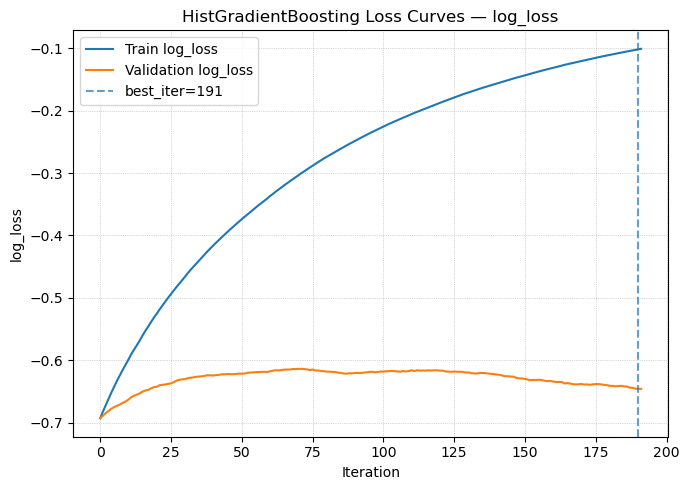


Val-basiertes Threshold-Tuning (F1-Maximum): {'best_f1': 0.7388987566607461, 'precision_at_best': 0.5909090909090909, 'recall_at_best': 0.985781990521327, 'threshold': 0.11087524807229633}


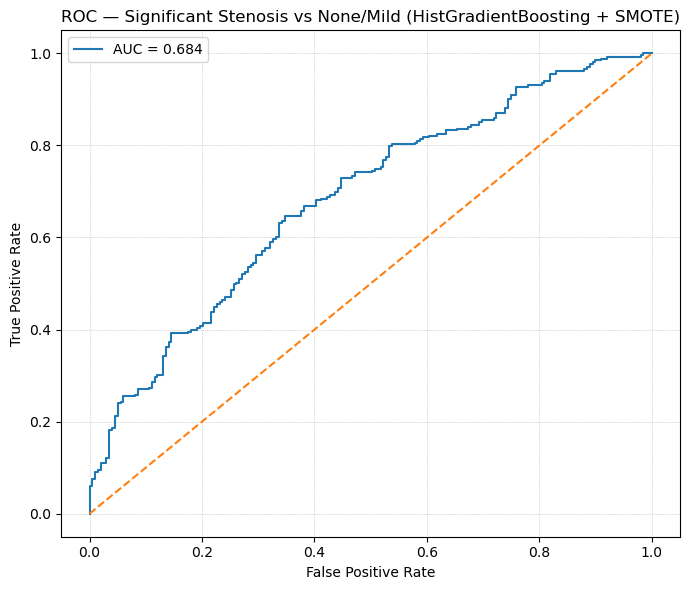

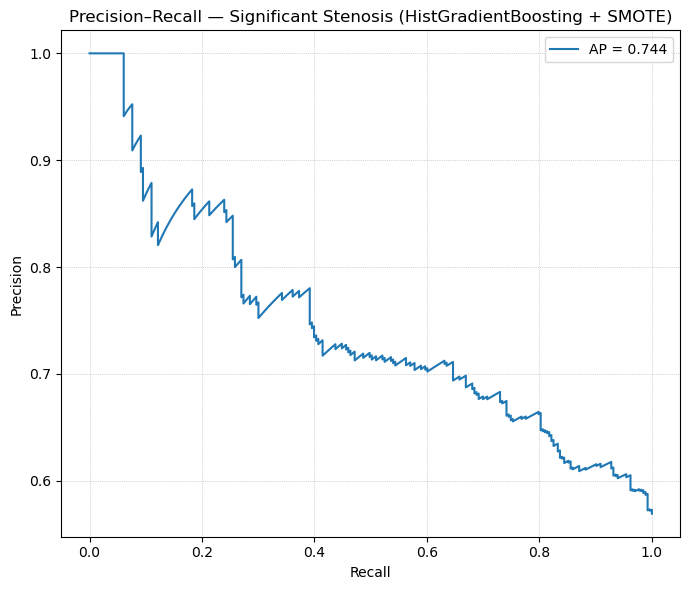


=== Evaluation Summary ===
Decision threshold:      0.111
Accuracy:                0.604
Balanced accuracy:       0.544
F1:                      0.737
ROC AUC:                 0.684
Average Precision (AP):  0.744

Confusion Matrix [rows=true, cols=pred] (labels=[0,1]):
 [[ 22 177]
 [  6 257]]

Classification Report:
               precision    recall  f1-score   support

           0      0.786     0.111     0.194       199
           1      0.592     0.977     0.737       263

    accuracy                          0.604       462
   macro avg      0.689     0.544     0.466       462
weighted avg      0.676     0.604     0.503       462


Formen nach Preprocessing:
Train (pre-enc): (1478, 100)
Train (after SMOTE): (1682, 100)
Val:   (370, 100)
Test:  (462, 100)


In [69]:
# -*- coding: utf-8 -*-
"""
HistGradientBoosting Binary Classifier – stabile Pipeline mit optionalem SMOTE,
Early Stopping (sklearn-intern), konservativ-kräftigere Defaults,
Threshold-Tuning (F1), vollständige Evaluation
und Loss-Kurven (Train & Validation) für log_loss.
Hinweis: Die Validationskurve kommt aus dem internen Early-Stopping-Split von HGB.
"""

import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# ============================================================
# Hilfsfunktionen (Data/Preprocessing)
# ============================================================
def read_csv_decimal_comma(path: str) -> pd.DataFrame:
    return pd.read_csv(
        path, sep=";", decimal=",",
        na_values=["", " ", "NA", "N/A", "NaN", "nan", None],
        low_memory=False
    )

def coerce_numeric_like_objects(df: pd.DataFrame, min_numeric_share: float = 0.80) -> pd.DataFrame:
    df = df.copy()
    obj_cols = df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        s = df[c].astype(str).str.strip()
        num = pd.to_numeric(s.replace(",", ".", regex=False), errors="coerce")
        if num.notna().mean() >= min_numeric_share:
            df[c] = num
    return df

def drop_high_missing(X: pd.DataFrame, threshold: float = 0.75) -> Tuple[pd.DataFrame, list]:
    miss = X.isna().mean()
    to_drop = miss[miss > threshold].index.tolist()
    X2 = X.drop(columns=to_drop)
    X2 = X2.loc[~X2.isna().all(axis=1)]
    return X2, to_drop

def _make_ohe_backward_compatible() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)  # sklearn >=1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=False)        # sklearn <1.2

def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    numeric = Pipeline([("imp", SimpleImputer(strategy="median"))])
    categorical = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                            ("ohe", _make_ohe_backward_compatible())])

    pre = ColumnTransformer(
        transformers=[("num", numeric, num_cols),
                      ("cat", categorical, cat_cols)],
        remainder="drop",
        verbose_feature_names_out=False
    )
    return pre

# ============================================================
# Metrics/Plots
# ============================================================
def choose_best_threshold(y_true: np.ndarray, y_score: np.ndarray) -> Tuple[float, Dict[str, float]]:
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    thresholds = np.append(thresholds, 1.0)
    f1_vals = 2 * (precision * recall) / np.clip(precision + recall, 1e-12, None)
    best_idx = int(np.nanargmax(f1_vals))
    thr = float(thresholds[best_idx])
    metrics = {
        "best_f1": float(f1_vals[best_idx]),
        "precision_at_best": float(precision[best_idx]),
        "recall_at_best": float(recall[best_idx]),
        "threshold": thr,
    }
    return thr, metrics

def _plot_loss_curves_from_model(model: HistGradientBoostingClassifier, best_iter: Optional[int]):
    train_scores = getattr(model, "train_score_", None)   # negative log_loss (je kleiner desto besser)
    val_scores   = getattr(model, "validation_score_", None)

    if train_scores is None and val_scores is None:
        print("Keine Trainings-/Validationskurven verfügbar (prüfe sklearn-Version / Early-Stopping-Settings).")
        return

    plt.figure(figsize=(7, 5))
    if train_scores is not None:
        plt.plot(train_scores, label="Train log_loss")
    if val_scores is not None:
        plt.plot(val_scores, label="Validation log_loss")
    if best_iter is not None:
        plt.axvline(best_iter - 1, linestyle="--", alpha=0.7, label=f"best_iter={best_iter}")
    plt.xlabel("Iteration")
    plt.ylabel("log_loss")
    plt.title("HistGradientBoosting Loss Curves — log_loss")
    plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5); plt.tight_layout(); plt.show()

def evaluate(
    model: HistGradientBoostingClassifier,
    X_test: np.ndarray,
    y_test: np.ndarray,
    decision_threshold: float = 0.5,
    title_suffix: str = ""
) -> Dict[str, Any]:
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= decision_threshold).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    report = classification_report(y_test, y_pred, digits=3)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC — Significant Stenosis vs None/Mild" + (f" {title_suffix}" if title_suffix else ""))
    plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall — Significant Stenosis" + (f" {title_suffix}" if title_suffix else ""))
    plt.legend(); plt.grid(True, linestyle=":", linewidth=0.5); plt.tight_layout(); plt.show()

    print("\n=== Evaluation Summary ===")
    print(f"Decision threshold:      {decision_threshold:.3f}")
    print(f"Accuracy:                {acc:.3f}")
    print(f"Balanced accuracy:       {bacc:.3f}")
    print(f"F1:                      {f1:.3f}")
    print(f"ROC AUC:                 {roc_auc:.3f}")
    print(f"Average Precision (AP):  {avg_precision:.3f}")
    print("\nConfusion Matrix [rows=true, cols=pred] (labels=[0,1]):\n", cm)
    print("\nClassification Report:\n", report)

    return {
        "threshold": decision_threshold,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1": f1,
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }

# ============================================================
# Optionales SMOTE (nur auf Train, nach Encoding)
# ============================================================
def maybe_apply_smote(Xtr: np.ndarray, ytr: np.ndarray, use_smote: bool = True) -> Tuple[np.ndarray, np.ndarray, bool]:
    if not use_smote:
        return Xtr, ytr, False
    try:
        from imblearn.over_sampling import SMOTE
        n_pos = int((ytr == 1).sum())
        n_neg = int((ytr == 0).sum())
        n_min = min(n_pos, n_neg)
        k = max(1, min(5, n_min - 1))  # SMOTE benötigt mind. k+1 Minderheitsbeispiele
        sm = SMOTE(k_neighbors=k, random_state=42)
        Xtr_sm, ytr_sm = sm.fit_resample(Xtr, ytr)
        return Xtr_sm, ytr_sm, True
    except Exception as e:
        print("SMOTE konnte nicht ausgeführt werden. Fallback ohne SMOTE.")
        print("Fehlermeldung:", e)
        return Xtr, ytr, False

# ============================================================
# HGB-Training (Early Stopping + Scores)
# ============================================================
def train_hgb_with_es(
    X_train: np.ndarray, y_train: np.ndarray,
    early_stopping: bool = True,
    validation_fraction: float = 0.15,
    max_iter: int = 3000,
    n_iter_no_change: int = 100,
    sample_weight: Optional[np.ndarray] = None,
) -> Tuple[HistGradientBoostingClassifier, Optional[int], Dict[str, Dict[str, list]]]:
    """
    Trainiert HistGradientBoostingClassifier mit Early Stopping.
    eval_history nutzt train_score_ und validation_score_ (interner Split).
    """
    model = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.03,
        max_iter=max_iter,
        early_stopping=early_stopping,
        n_iter_no_change=n_iter_no_change,
        validation_fraction=validation_fraction if early_stopping else None,
        max_leaf_nodes=48,
        max_depth=None,          # durch max_leaf_nodes begrenzt
        min_samples_leaf=20,
        l2_regularization=0.1,
        max_bins=255,
        class_weight=None,       # wir gewichten über sample_weight
        monotonic_cst=None,
        random_state=42
    )
    model.fit(X_train, y_train, sample_weight=sample_weight)

    best_iter = getattr(model, "n_iter_", None)
    # eval_history im selben Format wie zuvor
    eval_history: Dict[str, Dict[str, list]] = {}
    tr = getattr(model, "train_score_", None)
    va = getattr(model, "validation_score_", None)
    if tr is not None:
        eval_history.setdefault("train", {})["log_loss"] = list(tr)
    if va is not None:
        eval_history.setdefault("validation_0", {})["log_loss"] = list(va)
    return model, best_iter, eval_history

# ============================================================
# Hauptablauf
# ============================================================
def main(
    file_path: str = "T49.2_Sep2025_1_StGallen.csv",
    target_col: str = "OUTCOME_3Kat_KHK",
    positive_value: int = 2,
    test_size: float = 0.20,
    val_size_inside_train: float = 0.20,
    use_smote: bool = True
):
    # 1) Laden + numerische Konvertierung
    df = read_csv_decimal_comma(file_path)
    df = coerce_numeric_like_objects(df, min_numeric_share=0.80)

    if target_col not in df.columns:
        raise ValueError(f"Zielspalte '{target_col}' fehlt.")

    y = (df[target_col] == positive_value).astype(int)
    X = df.drop(columns=[target_col])

    # 2) High-Missing-Drop
    X, dropped = drop_high_missing(X, threshold=0.75)
    if dropped:
        print(f"Entfernte Spalten wegen Missing >75%: {len(dropped)}")

    # 3) Index angleichen
    common_idx = X.index.intersection(y.index)
    X = X.loc[common_idx]
    y = y.loc[common_idx]

    # 4) Externer Testsplit
    X_train_all, X_test, y_train_all, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # 5) Interner Val-Split (für Threshold-Tuning/Evaluation)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_all, y_train_all, test_size=val_size_inside_train, random_state=42, stratify=y_train_all
    )

    print("\nKlassenverteilung (Train/Val/Test):")
    for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        vc = yy.value_counts(normalize=True).sort_index().rename("proportion")
        print(f"{name}:\n{vc}\n")

    # 6) Preprocessing
    pre = make_preprocessor(X_train)
    pre.fit(X_train, y_train)
    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_val)
    Xte = pre.transform(X_test)

    # 7) Optional SMOTE nur auf Train (nach Encoding!)
    ytr_np = y_train.to_numpy()
    Xtr_sm, ytr_sm, smote_used = maybe_apply_smote(Xtr, ytr_np, use_smote=use_smote)
    if smote_used:
        print("SMOTE angewandt.")
        print(pd.Series(ytr_sm).value_counts(normalize=True).rename("proportion"))

    # 8) Imbalance-Gewichtung via sample_weight (balanced)
    #    Wenn SMOTE genutzt und praktisch ausgeglichen, keine Zusatz-Gewichtung.
    if smote_used:
        pos = int((ytr_sm == 1).sum()); neg = int((ytr_sm == 0).sum())
        balanced_after_smote = (max(pos, neg) > 0) and (abs(pos - neg) / max(pos, neg) < 0.05)
        sw = None if balanced_after_smote else compute_sample_weight("balanced", ytr_sm)
    else:
        sw = compute_sample_weight("balanced", ytr_sm)

    # 9) Train HGB mit Early Stopping (interner Val-Split)
    model, best_iter, eval_history = train_hgb_with_es(
        X_train=Xtr_sm, y_train=ytr_sm,
        early_stopping=True,
        validation_fraction=0.15,
        max_iter=3000,
        n_iter_no_change=120,
        sample_weight=sw
    )
    print(f"Early Stopping aktiv: {best_iter is not None} | Best iteration: {best_iter}")
    print(f"SMOTE: {smote_used}")

    # 10) Loss-Kurven (Train & Validation) aus dem Modell
    _plot_loss_curves_from_model(model, best_iter)

    # 11) Threshold-Tuning (Val)
    yva_prob = model.predict_proba(Xva)[:, 1]
    best_thr, thr_metrics = choose_best_threshold(y_val.to_numpy(), yva_prob)
    print(f"\nVal-basiertes Threshold-Tuning (F1-Maximum): {thr_metrics}")

    # 12) Test-Evaluation
    eval_res = evaluate(
        model,
        X_test=Xte,
        y_test=y_test.to_numpy(),
        decision_threshold=best_thr,
        title_suffix="(HistGradientBoosting " + ("+ SMOTE)" if smote_used else "ohne SMOTE)")
    )

    # 13) Shapes
    print("\nFormen nach Preprocessing:")
    print(f"Train (pre-enc): {Xtr.shape}")
    print(f"Train (after SMOTE): {Xtr_sm.shape}")
    print(f"Val:   {Xva.shape}")
    print(f"Test:  {Xte.shape}")

    return {
        "model": model,
        "preprocessor": pre,
        "best_iteration": best_iter,
        "threshold": best_thr,
        "fit_info": {"smote_used": smote_used},
        "eval": eval_res,
    }

# ============================================================
# Ausführen
# ============================================================
if __name__ == "__main__":
    _ = main(
        file_path="T49.2_Sep2025_1_StGallen.csv",
        target_col="OUTCOME_3Kat_KHK",
        positive_value=2,
        test_size=0.20,
        val_size_inside_train=0.20,
        use_smote=True  # <- SMOTE hier ein/aus
    )
